# Эскалация в СМИ как предиктор военной агрессии: кейс США — Венесуэла

**Данные:** GDELT 1.0 Event Export (data.gdeltproject.org), события с участием США и Венесуэлы,
окно **16.12.2025 — 02.01.2026** (18 дней по `DATEADDED`), 3 742 строки, 58 колонок.

**Гипотеза исследования:** вероятность военной агрессии одного государства против другого можно
предсказать по интенсивности освещения эскалации их отношений в СМИ.

**День X** — захват Мадуро, **3 января 2026**. В данных его нет: окно намеренно обрывается 2 января,
потому что проверяется предсказание **до** события, а не описание уже случившегося.

**Временная ось:** `DATEADDED` (дата обработки статьи GDELT — момент, когда информация реально
появилась в медиапотоке), а не `SQLDATE` (дата самого события, которая может быть в прошлом).

---

### Структура отчёта

1. Загрузка и первичная проверка
2. EDA — разведочный анализ
3. Предобработка
4. Метрики дневного агрегата
5. Группировка: ранний и поздний периоды
6. Проверка трёх гипотез + поправка Бонферрони
7. Визуализация
8. Выводы, интерпретация и ограничения

## 0. Настройка окружения

In [1]:
import warnings, re, os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.dates import DateFormatter, DayLocator
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# --- Палитра (валидированная, CVD-safe; светлая поверхность) -------------------
SURFACE   = "#fcfcfb"   # поверхность графика
INK       = "#0b0b0b"   # основной текст
INK_2     = "#52514e"   # вторичный текст
MUTED     = "#898781"   # подписи осей
GRID      = "#e1e0d9"   # сетка
AXIS      = "#c3c2b7"   # оси
BLUE      = "#2a78d6"   # серия 1
ORANGE    = "#eb6834"   # серия 2
AQUA      = "#1baf7a"   # серия 3
CRITICAL  = "#d03b3b"   # статус: критично
GOOD      = "#0ca30c"   # статус: норма
SEQ_BLUE  = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
# Расходящаяся шкала: синий <-> красный, нейтральный серый в середине
DIVERGING = LinearSegmentedColormap.from_list(
    "div_blue_red",
    ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#efa9a8", "#d03b3b", "#8f2020"],
)
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlepad": 26, "axes.labelsize": 10.5, "axes.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_2,
    "lines.linewidth": 2.0, "lines.markersize": 5.5,
})

def subtitle(ax, text):
    # Подзаголовок под заголовком графика
    ax.annotate(text, xy=(0, 1.012), xycoords="axes fraction",
                fontsize=9.5, color=MUTED, ha="left", va="bottom")

print("Окружение готово. pandas", pd.__version__, "| numpy", np.__version__)

Окружение готово. pandas 3.0.5 | numpy 2.4.6


---
## 1. Загрузка и первичная проверка

In [2]:
CSV_PATH = "data/usa_venezuela_gdelt.csv"   # выгрузка GDELT 1.0, разделитель — запятая, заголовок в 1-й строке

df = pd.read_csv(CSV_PATH, encoding="utf-8", low_memory=False)

print("Размерность (строк, колонок):", df.shape)
print("\nПервые 3 строки основных колонок:")
display(df[["GLOBALEVENTID", "SQLDATE", "DATEADDED", "Actor1CountryCode", "Actor2CountryCode",
            "EventRootCode", "QuadClass", "GoldsteinScale", "AvgTone", "NumArticles"]].head(3))

Размерность (строк, колонок): (3742, 58)

Первые 3 строки основных колонок:


,GLOBALEVENTID,SQLDATE,DATEADDED,Actor1CountryCode,Actor2CountryCode,EventRootCode,QuadClass,GoldsteinScale,AvgTone,NumArticles
0,1279456736,20251116,20251216,VEN,USA,11,3,-2.0000,-6.5663,1
1,1279456737,20251116,20251216,VEN,USA,14,3,-6.5000,-6.5663,1
2,1279456738,20251116,20251216,VEN,USA,14,3,-6.5000,-6.5663,5


In [3]:
# Типы и полный список колонок
info = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "non_null": df.notna().sum().values,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
})
display(info)

,column,dtype,non_null,n_unique
0,GLOBALEVENTID,int64,3742,3742
1,SQLDATE,int64,3742,30
2,MonthYear,int64,3742,4
3,Year,int64,3742,3
4,FractionDate,float64,3742,30
5,Actor1Code,str,3742,31
6,Actor1Name,str,3742,71
7,Actor1CountryCode,str,3742,2
8,Actor1KnownGroupCode,float64,0,0
9,Actor1EthnicCode,float64,0,0


In [4]:
# Приведение дат: DATEADDED — основная ось, SQLDATE — дата самого события
df["date_added"] = pd.to_datetime(df["DATEADDED"].astype(str), format="%Y%m%d")
df["sql_date"]   = pd.to_datetime(df["SQLDATE"].astype(str),   format="%Y%m%d")

print("DATEADDED: с", df.date_added.min().date(), "по", df.date_added.max().date(),
      "| уникальных дней:", df.date_added.nunique())
print("SQLDATE:   с", df.sql_date.min().date(),   "по", df.sql_date.max().date(),
      "| уникальных дней:", df.sql_date.nunique())

# Проверка непрерывности по дням DATEADDED
full_range = pd.date_range(df.date_added.min(), df.date_added.max(), freq="D")
present    = pd.DatetimeIndex(sorted(df.date_added.unique()))
missing_days = full_range.difference(present)
print("\nОжидаемая длина окна:", len(full_range), "дн. | фактически присутствует:", len(present), "дн.")
print("Пропущенные дни:", "нет" if len(missing_days) == 0 else list(missing_days.date))

# Насколько SQLDATE отстаёт от DATEADDED
lag = (df.date_added - df.sql_date).dt.days
print("\nЛаг DATEADDED - SQLDATE (дней): медиана", int(lag.median()),
      "| 90-й перцентиль", int(lag.quantile(0.9)), "| максимум", int(lag.max()))
print("Строк, где событие датировано ранее 01.12.2025 (архивные упоминания):",
      int((df.sql_date < '2025-12-01').sum()))

DATEADDED: с 2025-12-16 по 2026-01-02 | уникальных дней: 18
SQLDATE:   с 2015-12-29 по 2026-01-02 | уникальных дней: 30

Ожидаемая длина окна: 18 дн. | фактически присутствует: 18 дн.
Пропущенные дни: нет

Лаг DATEADDED - SQLDATE (дней): медиана 0 | 90-й перцентиль 0 | максимум 3650
Строк, где событие датировано ранее 01.12.2025 (архивные упоминания): 18


**Вывод по разделу 1.** Загружено 3 742 события × 58 колонок. По `DATEADDED` данные покрывают
ровно 18 календарных дней 16.12.2025 — 02.01.2026 **без пропусков**: каждый день окна представлен.
`SQLDATE` растянут на 30 уникальных дат и уходит вплоть до 2015 года — это статьи, которые в
декабре 2025 ссылались на старые события. Именно поэтому дальше в качестве временной оси берётся
`DATEADDED`: медианный лаг равен 0 дней, то есть в подавляющем большинстве случаев событие и его
попадание в медиапоток совпадают, а «хвост» архивных упоминаний (18 строк старше 01.12.2025)
не искажает дневную динамику.

---
## 2. EDA — разведочный анализ

### 2.1 Пропуски по колонкам

In [5]:
na = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
}).sort_values("n_missing", ascending=False)

print("Колонки с пропусками:")
display(na[na.n_missing > 0])
print("Колонок полностью без пропусков:", int((na.n_missing == 0).sum()), "из", df.shape[1])

Колонки с пропусками:


,n_missing,pct_missing
Actor1KnownGroupCode,3742,100.0000
Actor1EthnicCode,3742,100.0000
Actor1Religion1Code,3742,100.0000
Actor1Religion2Code,3742,100.0000
Actor2Religion1Code,3742,100.0000
Actor2KnownGroupCode,3742,100.0000
Actor2Type3Code,3742,100.0000
Actor2Religion2Code,3742,100.0000
Actor2EthnicCode,3742,100.0000
Actor1Type3Code,3742,100.0000


Колонок полностью без пропусков: 46 из 60


**Вывод.** Пропуски сконцентрированы в справочных атрибутах акторов: полностью пусты
`Actor*KnownGroupCode`, `Actor*EthnicCode`, `Actor*Religion*Code` (100 % NaN — GDELT заполняет их
редко), а `Actor1Type1Code` / `Actor2Type1Code` пусты на ~79 % / ~84 %. Это важно для метрики
доли военных акторов (`MIL`): отсутствие кода — это «тип не размечен», а не «не военный»,
поэтому доля MIL будет систематически занижена и трактуется как нижняя оценка.
**Все ключевые для анализа колонки** (`DATEADDED`, `GoldsteinScale`, `AvgTone`, `NumArticles`,
`NumMentions`, `EventRootCode`, `QuadClass`, `IsRootEvent`, `ActionGeo_CountryCode`, `SOURCEURL`)
заполнены на 100 %.

### 2.2 Распределение числа событий по дням

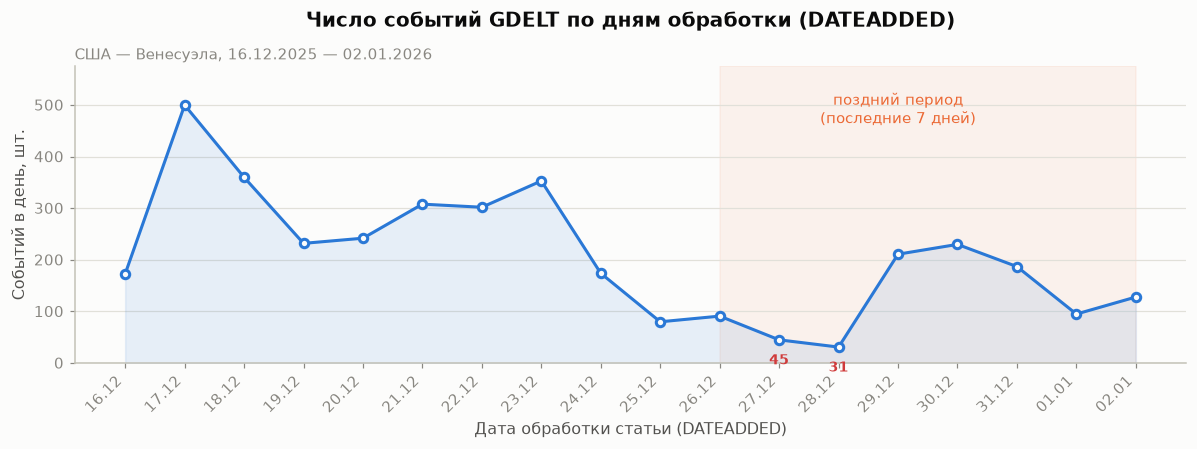

date_added,2025-12-16,2025-12-17,2025-12-18,2025-12-19,2025-12-20,2025-12-21,2025-12-22,2025-12-23,2025-12-24,2025-12-25,2025-12-26,2025-12-27,2025-12-28,2025-12-29,2025-12-30,2025-12-31,2026-01-01,2026-01-02
events,173,500,360,232,242,308,302,353,174,80,91,45,31,211,230,187,95,128


In [6]:
by_day = df.groupby("date_added").size().rename("events")

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(by_day.index, by_day.values, color=BLUE, marker="o",
        markerfacecolor=SURFACE, markeredgecolor=BLUE, markeredgewidth=2, zorder=3)
ax.fill_between(by_day.index, by_day.values, color=BLUE, alpha=0.10, zorder=2)
ax.axvspan(pd.Timestamp("2025-12-26"), pd.Timestamp("2026-01-02"), color=ORANGE, alpha=0.07, zorder=1)
ax.annotate("поздний период\n(последние 7 дней)", xy=(pd.Timestamp("2025-12-29"), by_day.max() * 0.93),
            color=ORANGE, fontsize=9.5, ha="center")
for d in [pd.Timestamp("2025-12-27"), pd.Timestamp("2025-12-28")]:
    ax.annotate(f"{by_day[d]}", xy=(d, by_day[d]), xytext=(0, -16), textcoords="offset points",
                color=CRITICAL, fontsize=9, ha="center", fontweight="bold")
ax.set_title("Число событий GDELT по дням обработки (DATEADDED)")
subtitle(ax, "США — Венесуэла, 16.12.2025 — 02.01.2026")
ax.set_xlabel("Дата обработки статьи (DATEADDED)"); ax.set_ylabel("Событий в день, шт.")
ax.set_ylim(0, by_day.max() * 1.15)
ax.xaxis.set_major_locator(DayLocator(interval=1)); ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(); plt.show()

display(by_day.to_frame().T)

**Вывод.** Поток событий крайне неравномерен: пик 17.12 (500 событий) и глубокий провал
25–28.12 (80 / 91 / 45 / **31** событие). Провал приходится на рождественские праздники — это
характерный медиа-артефакт (редакции не работают), а не спад напряжённости. Затем поток
восстанавливается 29–30.12 (211 и 230) и снова падает 01.01. Практическое следствие: дневные
доли за 27–28.12 опираются на несколько десятков наблюдений и имеют огромную дисперсию —
на них нельзя строить выводы о тренде.

### 2.3 Распределения GoldsteinScale и AvgTone + проверка нормальности

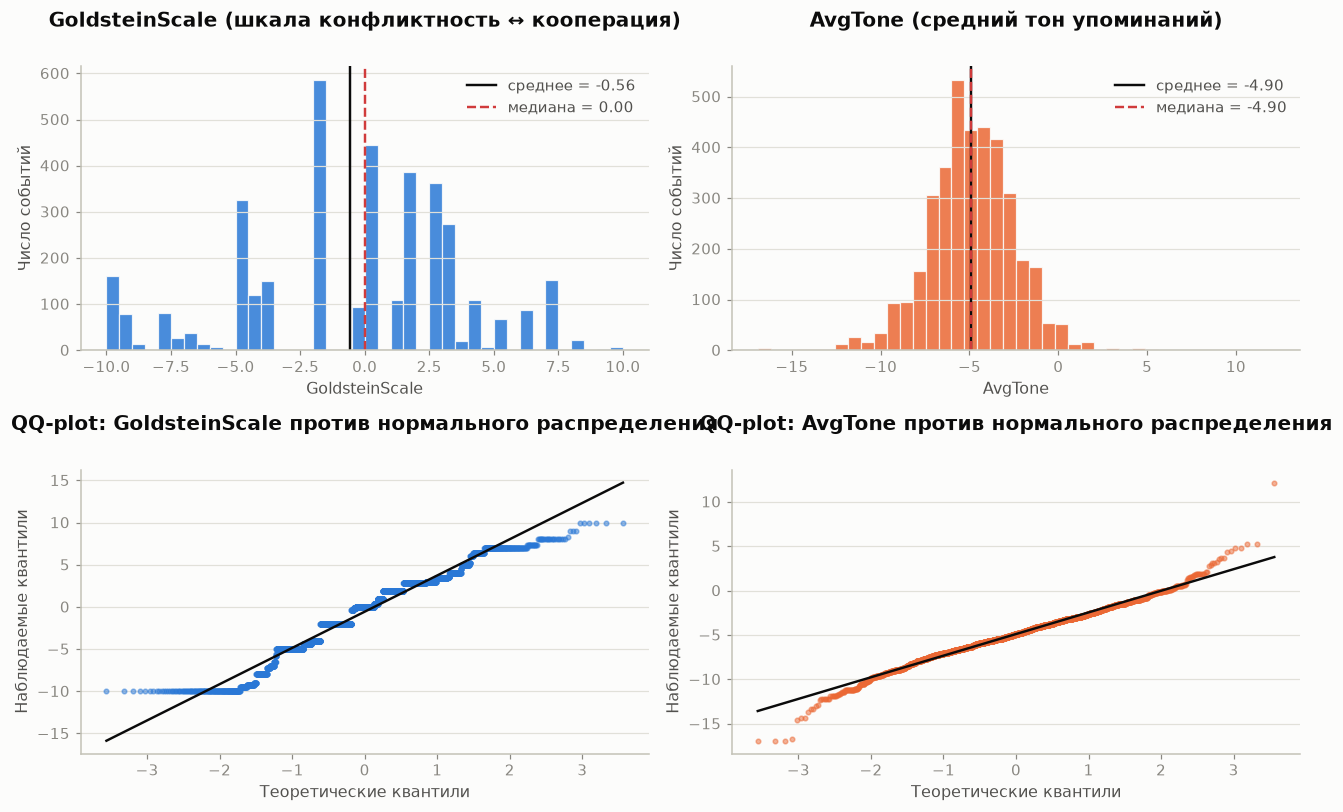

Тест Шапиро-Уилка (H0: выборка нормальна)
  GoldsteinScale  W = 0.9643   p = 1.799e-29   ->  НЕ нормально (H0 отвергается)   | асимметрия -0.37, эксцесс -0.41
  AvgTone         W = 0.9868   p = 2.994e-18   ->  НЕ нормально (H0 отвергается)   | асимметрия -0.07, эксцесс +1.80


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))

for j, (col, color, title) in enumerate([
        ("GoldsteinScale", BLUE,   "GoldsteinScale (шкала конфликтность ↔ кооперация)"),
        ("AvgTone",        ORANGE, "AvgTone (средний тон упоминаний)")]):
    x = df[col].dropna()

    ax = axes[0, j]
    ax.hist(x, bins=40, color=color, alpha=0.85, edgecolor=SURFACE, linewidth=0.8)
    ax.axvline(x.mean(),   color=INK,      lw=1.6, ls="-",  label=f"среднее = {x.mean():.2f}")
    ax.axvline(x.median(), color=CRITICAL, lw=1.6, ls="--", label=f"медиана = {x.median():.2f}")
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel("Число событий"); ax.legend()

    ax = axes[1, j]
    stats.probplot(x, dist="norm", plot=ax)
    ax.get_lines()[0].set(marker="o", markersize=3, color=color, alpha=0.5, linestyle="none")
    ax.get_lines()[1].set(color=INK, linewidth=1.6)
    ax.set_title(f"QQ-plot: {col} против нормального распределения")
    ax.set_xlabel("Теоретические квантили"); ax.set_ylabel("Наблюдаемые квантили")

plt.tight_layout(); plt.show()

print("Тест Шапиро-Уилка (H0: выборка нормальна)")
for col in ["GoldsteinScale", "AvgTone"]:
    x = df[col].dropna()
    W, p = stats.shapiro(x)
    print(f"  {col:<15} W = {W:.4f}   p = {p:.3e}   ->  "
          f"{'НЕ нормально (H0 отвергается)' if p < 0.05 else 'нормальность не отвергается'}"
          f"   | асимметрия {stats.skew(x):+.2f}, эксцесс {stats.kurtosis(x):+.2f}")

**Вывод — от него зависит выбор тестов в разделе 6.** Обе переменные нормальность не проходят:
Шапиро-Уилк даёт p ≈ 1,8·10⁻²⁹ для `GoldsteinScale` и p ≈ 3,0·10⁻¹⁸ для `AvgTone`, QQ-plot`ы явно
изогнуты на хвостах. `GoldsteinScale` вообще не непрерывен — это дискретный справочник значений,
жёстко привязанный к коду события (отсюда «гребёнка» в гистограмме и ступени на QQ-plot);
`AvgTone` ближе к нормальному, но с тяжёлыми хвостами и заметной асимметрией.
→ **Основным тестом для гипотезы A берём непараметрический тест Манна-Уитни**, t-тест Уэлча
считаем параллельно как справочный (при n ≈ 1 000–2 700 ЦПТ делает его устойчивым, и полезно
показать, что оба теста дают один и тот же вывод).

### 2.4 Уникальные статьи против строк-событий: поиск дней, «раздутых» одной статьёй

In [8]:
vol = df.groupby("date_added").agg(
    rows=("GLOBALEVENTID", "size"),
    unique_urls=("SOURCEURL", "nunique"),
)
vol["rows_per_url"] = vol.rows / vol.unique_urls

# Доминирование: какая доля строк дня приходится на одну самую частую статью
dom = df.groupby("date_added")["SOURCEURL"].agg(
    top_url_rows=lambda s: s.value_counts().iloc[0],
    top_url=lambda s: s.value_counts().index[0],
)
vol = vol.join(dom)
vol["top_url_share_pct"] = (vol.top_url_rows / vol.rows * 100).round(1)

display(vol[["rows", "unique_urls", "rows_per_url", "top_url_rows", "top_url_share_pct"]].round(2))

THRESH = 10.0   # порог: одна статья даёт >=10 % всех строк дня
distorted = vol[vol.top_url_share_pct >= THRESH]
print(f"\nДНИ, ИСКАЖЁННЫЕ ДОМИНИРОВАНИЕМ ОДНОЙ СТАТЬИ (>= {THRESH:.0f} % строк дня):")
for d, r in distorted.iterrows():
    print(f"  {d.date()}  —  {int(r.top_url_rows)} из {int(r.rows)} строк "
          f"({r.top_url_share_pct} %), строк на статью {r.rows_per_url:.2f}")
    print(f"      {r.top_url}")
DISTORTED_DAYS = list(distorted.index)

,rows,unique_urls,rows_per_url,top_url_rows,top_url_share_pct
date_added,,,,,
2025-12-16,173,76,2.2800,9,5.2000
2025-12-17,500,184,2.7200,14,2.8000
2025-12-18,360,127,2.8300,16,4.4000
2025-12-19,232,78,2.9700,9,3.9000
2025-12-20,242,83,2.9200,13,5.4000
2025-12-21,308,122,2.5200,11,3.6000
2025-12-22,302,118,2.5600,9,3.0000
2025-12-23,353,129,2.7400,15,4.2000
2025-12-24,174,74,2.3500,7,4.0000



ДНИ, ИСКАЖЁННЫЕ ДОМИНИРОВАНИЕМ ОДНОЙ СТАТЬИ (>= 10 % строк дня):
  2025-12-25  —  9 из 80 строк (11.2 %), строк на статью 2.35
      http://europe.chinadaily.com.cn/a/202512/25/WS694c8fada310d6866eb305c0.html
  2025-12-26  —  10 из 91 строк (11.0 %), строк на статью 2.94
      https://trinidadexpress.com/news/local/tensions-over-venezuela/article_673e8026-d91d-4782-9e53-143b914f1157.html
  2025-12-27  —  9 из 45 строк (20.0 %), строк на статью 2.37
      https://www.prokerala.com/news/articles/a1712002.html
  2025-12-28  —  15 из 31 строк (48.4 %), строк на статью 3.44
      https://economictimes.indiatimes.com/news/international/global-trends/how-oil-drugs-and-immigration-fueled-trumps-venezuela-campaign/articleshow/126211245.cms


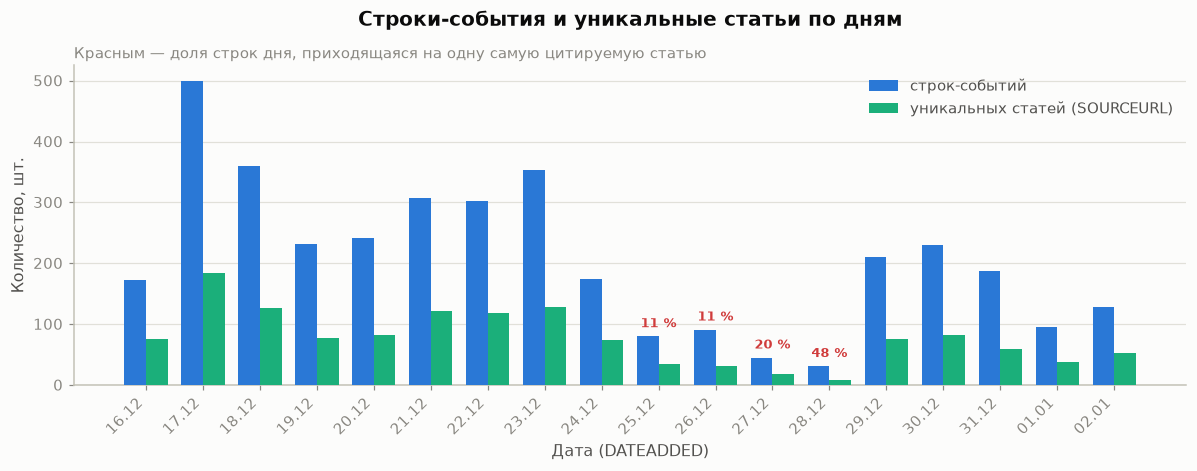

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.4))
w = 0.38
xs = np.arange(len(vol))
ax.bar(xs - w/2, vol.rows,        width=w, color=BLUE,  label="строк-событий", zorder=3)
ax.bar(xs + w/2, vol.unique_urls, width=w, color=AQUA,  label="уникальных статей (SOURCEURL)", zorder=3)
for i, d in enumerate(vol.index):
    if d in DISTORTED_DAYS:
        ax.annotate(f"{vol.top_url_share_pct[d]:.0f} %", xy=(i, vol.rows[d]), xytext=(0, 6),
                    textcoords="offset points", ha="center", fontsize=8.5,
                    color=CRITICAL, fontweight="bold")
ax.set_xticks(xs); ax.set_xticklabels([d.strftime("%d.%m") for d in vol.index], rotation=45, ha="right")
ax.set_title("Строки-события и уникальные статьи по дням")
subtitle(ax, "Красным — доля строк дня, приходящаяся на одну самую цитируемую статью")
ax.set_xlabel("Дата (DATEADDED)"); ax.set_ylabel("Количество, шт."); ax.legend()
plt.tight_layout(); plt.show()

**Вывод.** В среднем одна статья порождает 2,3–3,4 строки-события (GDELT дробит текст на пары
акторов), поэтому «число строк» ≠ «объём освещения». Критично то, что в четырёх днях одна
единственная статья даёт от 11 % до **48 %** всех строк дня:

| День | Доля строк из одной статьи | Всего строк |
|---|---|---|
| 25.12.2025 | 11,2 % | 80 |
| 26.12.2025 | 11,0 % | 91 |
| 27.12.2025 | 20,0 % | 45 |
| **28.12.2025** | **48,4 %** | **31** |

28 декабря почти половину «событий» дня сделала одна статья Economic Times про нефть, наркотики
и иммиграцию. **Три дня из четырёх (26, 27 и 28.12) попадают в поздний период** — тот самый, где
мы ищем рост конфликтности, а 25.12 — последний день раннего. К этому вернёмся в разделе 8.

### 2.5 Топ-10 самых частых SOURCEURL

In [10]:
top10 = df.SOURCEURL.value_counts().head(10).rename("rows").to_frame()
top10["days_present"] = [df.loc[df.SOURCEURL == u, "date_added"].nunique() for u in top10.index]
top10["first_day"]    = [df.loc[df.SOURCEURL == u, "date_added"].min().date() for u in top10.index]
top10["url_short"]    = [u[:95] + ("…" if len(u) > 95 else "") for u in top10.index]
display(top10.reset_index(drop=True)[["url_short", "rows", "days_present", "first_day"]])

,url_short,rows,days_present,first_day
0,https://grenadachronicle.com/trump-aide-stephe...,16,1,2025-12-18
1,https://news.az/news/-who-will-protect-venezue...,15,1,2025-12-23
2,https://economictimes.indiatimes.com/news/inte...,15,1,2025-12-28
3,https://dominicanrepublicpost.com/trump-aide-s...,14,1,2025-12-17
4,https://www.newsweek.com/us-hits-maduros-famil...,13,1,2025-12-20
5,https://nypost.com/2025/12/31/us-news/venezuel...,13,1,2025-12-31
6,https://theintercept.com/2025/12/29/trump-vene...,12,1,2025-12-31
7,https://metro.co.uk/2025/12/21/moment-us-seize...,11,1,2025-12-21
8,https://www.bankingnews.gr/diethni/articles/84...,11,1,2025-12-21
9,https://www.sbs.com.au/news/podcast-episode/us...,11,1,2025-12-23


**Вывод.** Лидеры — 11–16 строк на статью, и тематика однородна: нефть Венесуэлы и заявления
Стивена Миллера, санкции против семьи Мадуро, захват танкеров, американцы в венесуэльских
тюрьмах, «морская блокада». Две верхние ссылки (grenadachronicle / dominicanrepublicpost) — это
один и тот же перепечатанный текст на разных площадках: синдикация тиражирует одно сообщение
как независимые «события», и это ещё один канал искусственного раздувания счётчиков.

### 2.6 Выбросы по GoldsteinScale и AvgTone (метод IQR)

GoldsteinScale: границы IQR [-14.20; 13.00] -> выбросов 0 (0.0 %), из них снизу 0, сверху 0
AvgTone: границы IQR [-11.05; 1.34] -> выбросов 85 (2.3 %), из них снизу 52, сверху 33


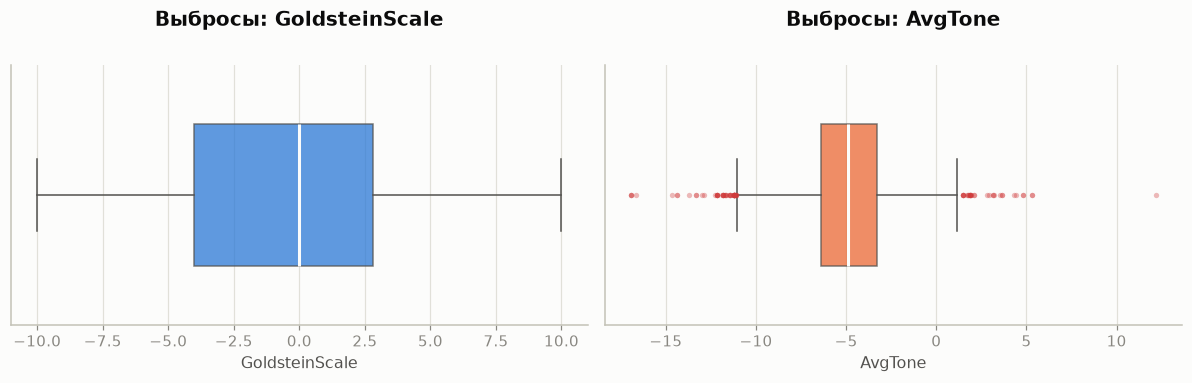


Самые конфликтные события (GoldsteinScale = -10): 160 строк; самые кооперативные (>= +7): 185 строк


In [11]:
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return lo, hi, s[(s < lo) | (s > hi)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (col, color) in zip(axes, [("GoldsteinScale", BLUE), ("AvgTone", ORANGE)]):
    s = df[col].dropna()
    lo, hi, out = iqr_outliers(s)
    print(f"{col}: границы IQR [{lo:.2f}; {hi:.2f}] -> выбросов {len(out)} "
          f"({len(out)/len(s)*100:.1f} %), из них снизу {int((out < lo).sum())}, сверху {int((out > hi).sum())}")
    bp = ax.boxplot(s, vert=False, widths=0.55, patch_artist=True,
                    flierprops=dict(marker="o", markersize=3.5, markerfacecolor=CRITICAL,
                                    markeredgecolor="none", alpha=0.35))
    bp["boxes"][0].set(facecolor=color, alpha=0.75, edgecolor=INK_2, linewidth=1.0)
    for el in ("whiskers", "caps"): [ln.set(color=INK_2, linewidth=1.0) for ln in bp[el]]
    bp["medians"][0].set(color=SURFACE, linewidth=2.0)
    ax.set_title(f"Выбросы: {col}"); ax.set_xlabel(col); ax.set_yticks([]); ax.grid(axis="x")
plt.tight_layout(); plt.show()

print("\nСамые конфликтные события (GoldsteinScale = -10):",
      int((df.GoldsteinScale == -10).sum()), "строк;",
      "самые кооперативные (>= +7):", int((df.GoldsteinScale >= 7).sum()), "строк")

**Вывод.** По `GoldsteinScale` формальных IQR-выбросов нет — шкала ограничена диапазоном
[-10; +10] и хорошо им заполнена; крайние значения (-10 — «военная атака») содержательны и
удалять их нельзя, это ровно тот сигнал, который мы ищем. По `AvgTone` выбросы есть в обе стороны
(85 наблюдений, 2,3 %: 52 снизу и 33 сверху), но и они содержательны: это либо очень негативные военные сводки, либо
редкие позитивные материалы. **Ни одно наблюдение не удаляем** — вместо этого в тестах опираемся
на непараметрику и медианы, устойчивые к хвостам.

---
## 3. Предобработка

In [12]:
KEY_COLS = ["DATEADDED", "GoldsteinScale", "AvgTone", "NumArticles", "NumMentions", "NumSources",
            "EventRootCode", "QuadClass", "IsRootEvent", "ActionGeo_CountryCode", "SOURCEURL"]

print("ПРОПУСКИ В КЛЮЧЕВЫХ КОЛОНКАХ (ни одна строка не удаляется молча):")
for c in KEY_COLS:
    n = int(df[c].isna().sum())
    print(f"  {c:<22} пропусков: {n:>4}  ({n/len(df)*100:.1f} %)")

print("\nПРОПУСКИ В КОЛОНКАХ ТИПОВ АКТОРОВ (используются только для доли MIL):")
for c in ["Actor1Type1Code", "Actor2Type1Code"]:
    n = int(df[c].isna().sum())
    print(f"  {c:<22} пропусков: {n:>4}  ({n/len(df)*100:.1f} %)  -> трактуем как «тип не размечен», не как «не MIL»")

# Явная политика: строки не удаляем, NaN в типах акторов -> "" (нет разметки)
df["Actor1Type1Code"] = df["Actor1Type1Code"].fillna("")
df["Actor2Type1Code"] = df["Actor2Type1Code"].fillna("")
print(f"\nСтрок до обработки: {len(df)} | после: {len(df)} (удалено 0)")

ПРОПУСКИ В КЛЮЧЕВЫХ КОЛОНКАХ (ни одна строка не удаляется молча):
  DATEADDED              пропусков:    0  (0.0 %)
  GoldsteinScale         пропусков:    0  (0.0 %)
  AvgTone                пропусков:    0  (0.0 %)
  NumArticles            пропусков:    0  (0.0 %)
  NumMentions            пропусков:    0  (0.0 %)
  NumSources             пропусков:    0  (0.0 %)
  EventRootCode          пропусков:    0  (0.0 %)
  QuadClass              пропусков:    0  (0.0 %)
  IsRootEvent            пропусков:    0  (0.0 %)
  ActionGeo_CountryCode  пропусков:    0  (0.0 %)
  SOURCEURL              пропусков:    0  (0.0 %)

ПРОПУСКИ В КОЛОНКАХ ТИПОВ АКТОРОВ (используются только для доли MIL):
  Actor1Type1Code        пропусков: 2945  (78.7 %)  -> трактуем как «тип не размечен», не как «не MIL»
  Actor2Type1Code        пропусков: 3145  (84.0 %)  -> трактуем как «тип не размечен», не как «не MIL»

Строк до обработки: 3742 | после: 3742 (удалено 0)


In [13]:
# --- Дедупликация по SOURCEURL: объём именно СТАТЕЙ, а не строк-событий -------
# Одна статья может породить несколько строк; для объёма освещения берём по одной строке на URL.
# Если URL встречается в разные дни, статья учитывается в день первого появления.
first_seen = df.sort_values("date_added").drop_duplicates(subset="SOURCEURL", keep="first")
print("Строк-событий:", len(df))
print("Уникальных статей (SOURCEURL):", df.SOURCEURL.nunique())
print("Строк после дедупликации по SOURCEURL:", len(first_seen))
print("Коэффициент раздувания (строк на статью):", round(len(df) / df.SOURCEURL.nunique(), 2))

articles_per_day = first_seen.groupby("date_added").agg(
    articles_dedup=("SOURCEURL", "size"),
    articles_dedup_numarticles=("NumArticles", "sum"),
)
display(articles_per_day.T)

Строк-событий: 3742
Уникальных статей (SOURCEURL): 1392
Строк после дедупликации по SOURCEURL: 1392
Коэффициент раздувания (строк на статью): 2.69


date_added,2025-12-16,2025-12-17,2025-12-18,2025-12-19,2025-12-20,2025-12-21,2025-12-22,2025-12-23,2025-12-24,2025-12-25,2025-12-26,2025-12-27,2025-12-28,2025-12-29,2025-12-30,2025-12-31,2026-01-01,2026-01-02
articles_dedup,76,184,127,78,83,122,118,129,74,34,31,19,9,75,83,59,38,53
articles_dedup_numarticles,420,2540,1157,357,1680,1977,1326,685,547,236,146,142,29,672,777,416,210,1619


In [14]:
# --- Дневной агрегат ---------------------------------------------------------
daily = df.groupby("date_added").agg(
    n_events            = ("GLOBALEVENTID", "size"),
    goldstein_mean      = ("GoldsteinScale", "mean"),
    goldstein_median    = ("GoldsteinScale", "median"),
    tone_mean           = ("AvgTone", "mean"),
    tone_median         = ("AvgTone", "median"),
    num_articles_sum    = ("NumArticles", "sum"),
    num_mentions_sum    = ("NumMentions", "sum"),
    num_sources_sum     = ("NumSources", "sum"),
    unique_urls         = ("SOURCEURL", "nunique"),
).join(articles_per_day)

daily.index.name = "date"
display(daily.round(3))

,n_events,goldstein_mean,goldstein_median,tone_mean,tone_median,num_articles_sum,num_mentions_sum,num_sources_sum,unique_urls,articles_dedup,articles_dedup_numarticles
date,,,,,,,,,,,
2025-12-16,173,-0.7540,0.0000,-4.8140,-5.1280,828,835,285,76,76,420
2025-12-17,500,0.3960,1.9000,-5.2080,-4.9440,8736,8807,3097,184,184,2540
2025-12-18,360,-0.0070,0.5000,-4.7220,-4.5970,2888,2929,899,127,127,1157
2025-12-19,232,-0.9150,-0.4000,-5.2570,-4.9750,1097,1118,399,78,78,357
2025-12-20,242,-1.5220,-2.0000,-5.1940,-5.4650,3285,3293,936,83,83,1680
2025-12-21,308,-0.8490,0.0000,-5.4250,-5.5510,4925,4955,1267,122,122,1977
2025-12-22,302,-0.0160,0.0000,-4.7730,-4.9080,3189,3218,1093,118,118,1326
2025-12-23,353,-0.7070,0.0000,-4.1810,-4.1620,1674,1719,698,129,129,685
2025-12-24,174,-1.5470,-2.0000,-4.8590,-4.5690,1233,1329,450,74,74,547


**Вывод по разделу 3.** Строки не удалялись: единственная обработка пропусков — коды типов
акторов, где NaN осознанно переведён в пустую строку со смыслом «тип не размечен».
Дедупликация по `SOURCEURL` показывает коэффициент раздувания **2,69 строки на статью**:
3 742 строки-события порождены всего 1 392 уникальными статьями. Поэтому дальше объём освещения
меряется двумя независимыми способами — числом уникальных статей и суммой `NumArticles`, — а
«число строк» используется только как знаменатель для долей.

---
## 4. Метрики дневного агрегата

In [15]:
# --- Признаки на уровне события ---------------------------------------------
df["is_conflict_hard"] = df.EventRootCode.isin([18, 19, 20]).astype(int)   # assault / fight / mass violence
df["is_material_conf"] = (df.QuadClass == 4).astype(int)                   # material conflict
df["is_mil_actor"]     = ((df.Actor1Type1Code == "MIL") | (df.Actor2Type1Code == "MIL")).astype(int)
df["is_root_event"]    = (df.IsRootEvent == 1).astype(int)
df["neg_intensity"]    = np.where(df.GoldsteinScale < 0, df.NumArticles * df.GoldsteinScale, 0.0)

print("Распределение EventRootCode 18/19/20 по всей выборке:")
print(df.loc[df.is_conflict_hard == 1, "EventRootCode"].value_counts().sort_index().to_string())
print("\nВНИМАНИЕ: код 20 (unconventional mass violence) в выборке отсутствует —",
      "жёсткий конфликт представлен кодами 18 (assault) и 19 (fight).")
print("\nQuadClass:"); print(df.QuadClass.value_counts().sort_index().to_string())
print("\nСобытий с актором MIL:", int(df.is_mil_actor.sum()),
      f"({df.is_mil_actor.mean()*100:.1f} % — нижняя оценка из-за пропусков в Type1Code)")

Распределение EventRootCode 18/19/20 по всей выборке:
EventRootCode
18     19
19    190

ВНИМАНИЕ: код 20 (unconventional mass violence) в выборке отсутствует — жёсткий конфликт представлен кодами 18 (assault) и 19 (fight).

QuadClass:
QuadClass
1    1894
2     267
3     998
4     583

Событий с актором MIL: 164 (4.4 % — нижняя оценка из-за пропусков в Type1Code)


In [16]:
# --- Дневные метрики ---------------------------------------------------------
m = df.groupby("date_added").agg(
    conflict_hard_share     = ("is_conflict_hard", "mean"),
    material_conflict_share = ("is_material_conf", "mean"),
    mil_actor_share         = ("is_mil_actor", "mean"),
    root_event_share        = ("is_root_event", "mean"),
    negative_intensity_index= ("neg_intensity", "sum"),
    geo_diversity           = ("ActionGeo_CountryCode", "nunique"),
)
daily = daily.join(m)

# --- Первая и вторая разности (динамика и ускорение) -------------------------
for col in ["goldstein_mean", "tone_mean", "material_conflict_share"]:
    daily[f"d1_{col}"] = daily[col].diff()        # сегодня минус вчера
    daily[f"d2_{col}"] = daily[f"d1_{col}"].diff()  # ускорение

# --- Скользящие окна 3 дня ---------------------------------------------------
for col in ["goldstein_mean", "tone_mean"]:
    daily[f"roll3_mean_{col}"] = daily[col].rolling(3, min_periods=2).mean()
    daily[f"roll3_std_{col}"]  = daily[col].rolling(3, min_periods=2).std()

print("Метрики дневного агрегата:", list(daily.columns))
display(daily[["n_events", "unique_urls", "goldstein_mean", "tone_mean",
               "conflict_hard_share", "material_conflict_share", "mil_actor_share",
               "root_event_share", "negative_intensity_index", "geo_diversity"]].round(3))

Метрики дневного агрегата: ['n_events', 'goldstein_mean', 'goldstein_median', 'tone_mean', 'tone_median', 'num_articles_sum', 'num_mentions_sum', 'num_sources_sum', 'unique_urls', 'articles_dedup', 'articles_dedup_numarticles', 'conflict_hard_share', 'material_conflict_share', 'mil_actor_share', 'root_event_share', 'negative_intensity_index', 'geo_diversity', 'd1_goldstein_mean', 'd2_goldstein_mean', 'd1_tone_mean', 'd2_tone_mean', 'd1_material_conflict_share', 'd2_material_conflict_share', 'roll3_mean_goldstein_mean', 'roll3_std_goldstein_mean', 'roll3_mean_tone_mean', 'roll3_std_tone_mean']


,n_events,unique_urls,goldstein_mean,tone_mean,conflict_hard_share,material_conflict_share,mil_actor_share,root_event_share,negative_intensity_index,geo_diversity
date,,,,,,,,,,
2025-12-16,173,76,-0.7540,-4.8140,0.0640,0.1450,0.0460,0.4220,"-1,531.2000",14
2025-12-17,500,184,0.3960,-5.2080,0.0360,0.1000,0.0160,0.5140,"-6,354.8000",20
2025-12-18,360,127,-0.0070,-4.7220,0.0810,0.1330,0.0420,0.4610,"-4,525.8000",17
2025-12-19,232,78,-0.9150,-5.2570,0.0650,0.1940,0.0040,0.5000,"-2,590.8000",14
2025-12-20,242,83,-1.5220,-5.1940,0.0740,0.2070,0.0330,0.5950,"-11,297.5000",10
2025-12-21,308,122,-0.8490,-5.4250,0.0130,0.1690,0.1720,0.6430,"-9,234.9000",20
2025-12-22,302,118,-0.0160,-4.7730,0.0030,0.0860,0.0760,0.4870,"-2,657.8000",18
2025-12-23,353,129,-0.7070,-4.1810,0.0620,0.1590,0.0170,0.4930,"-3,565.2000",15
2025-12-24,174,74,-1.5470,-4.8590,0.0980,0.1840,0.0110,0.5800,"-3,693.0000",14


In [17]:
display(daily[["d1_goldstein_mean", "d2_goldstein_mean", "d1_tone_mean", "d2_tone_mean",
               "d1_material_conflict_share", "d2_material_conflict_share",
               "roll3_mean_goldstein_mean", "roll3_std_goldstein_mean",
               "roll3_mean_tone_mean", "roll3_std_tone_mean"]].round(3))

,d1_goldstein_mean,d2_goldstein_mean,d1_tone_mean,d2_tone_mean,d1_material_conflict_share,d2_material_conflict_share,roll3_mean_goldstein_mean,roll3_std_goldstein_mean,roll3_mean_tone_mean,roll3_std_tone_mean
date,,,,,,,,,,
2025-12-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-17,1.1510,NaN,-0.3940,NaN,-0.0450,NaN,-0.1790,0.8140,-5.0110,0.2790
2025-12-18,-0.4030,-1.5530,0.4860,0.8800,0.0330,0.0780,-0.1220,0.5840,-4.9150,0.2580
2025-12-19,-0.9080,-0.5050,-0.5350,-1.0200,0.0610,0.0270,-0.1750,0.6710,-5.0630,0.2960
2025-12-20,-0.6080,0.3000,0.0630,0.5970,0.0130,-0.0480,-0.8150,0.7630,-5.0580,0.2920
2025-12-21,0.6740,1.2810,-0.2310,-0.2940,-0.0380,-0.0500,-1.0950,0.3710,-5.2920,0.1190
2025-12-22,0.8330,0.1590,0.6520,0.8830,-0.0830,-0.0450,-0.7960,0.7550,-5.1310,0.3310
2025-12-23,-0.6910,-1.5240,0.5920,-0.0600,0.0730,0.1550,-0.5240,0.4460,-4.7930,0.6220
2025-12-24,-0.8400,-0.1490,-0.6770,-1.2690,0.0250,-0.0470,-0.7570,0.7670,-4.6040,0.3690


**Вывод по разделу 4.** Сформирован дневной агрегат: 18 дней × 27 метрик. Уже по таблице видно
главное напряжение кейса: `material_conflict_share` в конце окна держится на уровне
0,18–0,33 против 0,09–0,21 в начале, `negative_intensity_index` даёт резкие всплески (наиболее
сильные — 20.12 со значением -11 298 и 21.12 со значением -9 235), но `goldstein_mean` при этом «пилит» вокруг -1 без явного дрейфа вниз,
а вторые разности меняют знак почти каждый день — то есть устойчивого ускорения эскалации в
дневных данных нет, есть высокочастотный шум с амплитудой, сопоставимой с самим сигналом.

---
## 5. Группировка: ранний и поздний периоды

In [18]:
SPLIT = pd.Timestamp("2025-12-26")   # начало позднего периода (последние 7 дней окна)

df["period"]   = np.where(df.date_added >= SPLIT, "late", "early")
daily["period"] = np.where(daily.index >= SPLIT, "late", "early")

summary = pd.DataFrame({
    "период":            ["ранний (16.12–25.12)", "поздний (26.12–02.01)"],
    "дней":              [int((daily.period == "early").sum()), int((daily.period == "late").sum())],
    "событий":           [int((df.period == "early").sum()), int((df.period == "late").sum())],
    "уник. статей":      [df.loc[df.period == "early", "SOURCEURL"].nunique(),
                          df.loc[df.period == "late",  "SOURCEURL"].nunique()],
    "Goldstein среднее":  [df.loc[df.period == "early", "GoldsteinScale"].mean(),
                          df.loc[df.period == "late",  "GoldsteinScale"].mean()],
    "AvgTone среднее":    [df.loc[df.period == "early", "AvgTone"].mean(),
                          df.loc[df.period == "late",  "AvgTone"].mean()],
    "material_conflict_share": [df.loc[df.period == "early", "is_material_conf"].mean(),
                                df.loc[df.period == "late",  "is_material_conf"].mean()],
    "conflict_hard_share":     [df.loc[df.period == "early", "is_conflict_hard"].mean(),
                                df.loc[df.period == "late",  "is_conflict_hard"].mean()],
})
display(summary.round(4))

,период,дней,событий,уник. статей,Goldstein среднее,AvgTone среднее,material_conflict_share,conflict_hard_share
0,ранний (16.12–25.12),10,2724,1025,-0.5106,-4.9088,0.1450,0.0529
1,поздний (26.12–02.01),8,1018,367,-0.6990,-4.8656,0.1847,0.0639


**Вывод по разделу 5.** Периоды сильно несбалансированы по объёму: ранние 10 дней дают
2 724 события, поздние 7 дней — всего 1 018 (сказались праздники). Направление сдвигов
на первый взгляд согласуется с гипотезой эскалации: `GoldsteinScale` -0,51 → -0,70,
`material_conflict_share` 0,145 → 0,185, `conflict_hard_share` 0,053 → 0,064. Насколько эти
сдвиги отличимы от шума — проверяем дальше формально.

---
## 6. Проверка гипотез

Проверяются ровно три гипотезы; каждая — на двух показателях, итого **6 основных тестов**
(тест Манна-Кендалла добавляется как непараметрическая перепроверка тренда и в поправку
не включается, чтобы не наказывать за дублирующую проверку одного и того же утверждения).
Для каждого теста выводятся p-value и размер эффекта.

In [19]:
RESULTS = []   # сюда собираем всё для итоговой таблицы с поправкой Бонферрони

def cohens_d(a, b):
    # a — поздний период, b — ранний; знак показывает направление сдвига
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp

def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

def effect_label(v, kind):
    v = abs(v)
    bounds = {"d": (0.2, 0.5, 0.8), "h": (0.2, 0.5, 0.8), "r2": (0.02, 0.13, 0.26)}[kind]
    if v < bounds[0]: return "пренебрежимо малый"
    if v < bounds[1]: return "малый"
    if v < bounds[2]: return "средний"
    return "большой"

### Гипотеза A — сдвиг тона и интенсивности

- **H0:** средний `GoldsteinScale` (и отдельно `AvgTone`) в позднем периоде не отличается от раннего.
- **H1:** отличается (стал более негативным).
- **Тест:** по разделу 2.3 нормальность отвергнута → основной тест **Манна-Уитни**;
  t-тест Уэлча приводится параллельно как справочный.
- **Размер эффекта:** Cohen's d.

In [20]:
for col in ["GoldsteinScale", "AvgTone"]:
    late  = df.loc[df.period == "late",  col].dropna()
    early = df.loc[df.period == "early", col].dropna()

    U, p_mw = stats.mannwhitneyu(late, early, alternative="two-sided")
    t, p_t  = stats.ttest_ind(late, early, equal_var=False)
    d       = cohens_d(late, early)
    # ранговая бисериальная корреляция как непараметрический размер эффекта
    rb = 1 - 2 * U / (len(late) * len(early))

    print(f"--- {col} ---")
    print(f"  ранний  n={len(early):>5}  среднее={early.mean():+.4f}  медиана={early.median():+.2f}  sd={early.std():.3f}")
    print(f"  поздний n={len(late):>5}  среднее={late.mean():+.4f}  медиана={late.median():+.2f}  sd={late.std():.3f}")
    print(f"  сдвиг средних: {late.mean() - early.mean():+.4f}")
    print(f"  Манна-Уитни:  U = {U:,.0f}   p = {p_mw:.4f}")
    print(f"  t-тест Уэлча: t = {t:+.3f}   p = {p_t:.4f}")
    print(f"  Cohen's d = {d:+.4f} ({effect_label(d, 'd')}) | ранговая бисериальная r = {rb:+.4f}\n")

    RESULTS.append(dict(
        hypothesis="A: сдвиг тона/интенсивности",
        metric=col, test="Манна-Уитни (двусторонний)", p_value=p_mw,
        effect_name="Cohen's d", effect=d, effect_size=effect_label(d, "d"),
        detail=f"среднее {early.mean():+.3f} → {late.mean():+.3f}",
    ))

--- GoldsteinScale ---
  ранний  n= 2724  среднее=-0.5106  медиана=+0.00  sd=4.302
  поздний n= 1018  среднее=-0.6990  медиана=+0.00  sd=4.551
  сдвиг средних: -0.1884
  Манна-Уитни:  U = 1,339,745   p = 0.1104
  t-тест Уэлча: t = -1.144   p = 0.2530
  Cohen's d = -0.0431 (пренебрежимо малый) | ранговая бисериальная r = +0.0337

--- AvgTone ---
  ранний  n= 2724  среднее=-4.9088  медиана=-4.97  sd=2.440
  поздний n= 1018  среднее=-4.8656  медиана=-4.69  sd=2.483
  сдвиг средних: +0.0432
  Манна-Уитни:  U = 1,443,856   p = 0.0512
  t-тест Уэлча: t = +0.476   p = 0.6341
  Cohen's d = +0.0176 (пренебрежимо малый) | ранговая бисериальная r = -0.0414



**Вывод по гипотезе A.** Сдвиг есть в предсказанном направлении, но он ничтожен по величине.
`GoldsteinScale` сместился с -0,511 до -0,699 (p = 0,110 по Манна-Уитни, p = 0,253 по t-тесту),
Cohen's d = -0,043 — **пренебрежимо малый** эффект. `AvgTone` вообще не сдвинулся
(-4,909 → -4,866, p = 0,051, d = +0,018 — формально в сторону *менее* негативного тона).
H0 не отвергается ни для одной из двух переменных. Замечу: p = 0,051 у `AvgTone` при d = 0,018 —
классическая иллюстрация того, что на выборке в 3 742 наблюдения p-value ловит содержательно
нулевые различия, и смотреть надо на размер эффекта.

### Гипотеза B — рост доли конфликтных событий

- **H0:** доля `material_conflict_share` (и отдельно `conflict_hard_share`) не растёт от раннего периода к позднему.
- **H1:** растёт.
- **Тест:** z-тест для двух независимых пропорций **на уровне событий** (односторонний, «больше»).
- **Размер эффекта:** Cohen's h.

In [21]:
prop_specs = [("material_conflict_share", "is_material_conf", "QuadClass == 4"),
              ("conflict_hard_share",     "is_conflict_hard", "EventRootCode in {18,19,20}")]

for name, flag, definition in prop_specs:
    late  = df.loc[df.period == "late",  flag]
    early = df.loc[df.period == "early", flag]
    count = np.array([late.sum(), early.sum()])
    nobs  = np.array([len(late),  len(early)])
    z, p  = proportions_ztest(count, nobs, alternative="larger")
    p1, p2 = count[0] / nobs[0], count[1] / nobs[1]
    h = cohens_h(p1, p2)
    # 95 % ДИ для разности пропорций (Вальд)
    se = np.sqrt(p1 * (1 - p1) / nobs[0] + p2 * (1 - p2) / nobs[1])
    ci = (p1 - p2 - 1.96 * se, p1 - p2 + 1.96 * se)

    print(f"--- {name}  ({definition}) ---")
    print(f"  ранний:  {int(count[1]):>4} / {int(nobs[1]):>4} = {p2:.4f}")
    print(f"  поздний: {int(count[0]):>4} / {int(nobs[0]):>4} = {p1:.4f}")
    print(f"  разность: {p1 - p2:+.4f}  (95 % ДИ [{ci[0]:+.4f}; {ci[1]:+.4f}])")
    print(f"  z = {z:+.3f}   p (односторонний) = {p:.5f}")
    print(f"  Cohen's h = {h:+.4f} ({effect_label(h, 'h')})\n")

    RESULTS.append(dict(
        hypothesis="B: рост доли конфликтных событий",
        metric=name, test="z-тест пропорций (односторонний)", p_value=p,
        effect_name="Cohen's h", effect=h, effect_size=effect_label(h, "h"),
        detail=f"доля {p2:.3f} → {p1:.3f}",
    ))

--- material_conflict_share  (QuadClass == 4) ---
  ранний:   395 / 2724 = 0.1450
  поздний:  188 / 1018 = 0.1847
  разность: +0.0397  (95 % ДИ [+0.0124; +0.0669])
  z = +2.978   p (односторонний) = 0.00145
  Cohen's h = +0.1071 (пренебрежимо малый)

--- conflict_hard_share  (EventRootCode in {18,19,20}) ---
  ранний:   144 / 2724 = 0.0529
  поздний:   65 / 1018 = 0.0639
  разность: +0.0110  (95 % ДИ [-0.0062; +0.0282])
  z = +1.302   p (односторонний) = 0.09637
  Cohen's h = +0.0469 (пренебрежимо малый)



**Вывод по гипотезе B.** Разделение: **`material_conflict_share` растёт значимо** — 14,5 % → 18,5 %
(+4,0 п.п., 95 % ДИ [+0,8; +7,2] п.п., z = 2,98, p = 0,0015), но Cohen's h = 0,107 — это
**пренебрежимо малый** эффект по общепринятой шкале. `conflict_hard_share` (прямые нападения и
бои) растёт с 5,3 % до 6,4 %, но незначимо (z = 1,30, p = 0,096, h = 0,047). То есть в позднем
периоде прибавилось событий класса «материальный конфликт» в широком смысле (санкции, захваты
судов, демонстрации силы), но не событий прямого военного столкновения.

### Гипотеза C — наличие тренда во времени

- **H0:** тренда по дням нет (наклон регрессии = 0).
- **H1:** есть значимый тренд.
- **Тест:** линейная регрессия `GoldsteinScale` (и отдельно `material_conflict_share`) на номер дня 1…18 (МНК).
- **Дополнительно:** тест Манна-Кендалла — непараметрическая проверка монотонного тренда.

In [22]:
def mann_kendall(x, alpha=0.05):
    # Классический MK-тест с поправкой на связки; возвращает S, Z, p, тау и вердикт
    x = np.asarray(x, dtype=float); n = len(x)
    s = int(sum(np.sign(x[j] - x[i]) for i in range(n - 1) for j in range(i + 1, n)))
    _, cnt = np.unique(x, return_counts=True)
    var_s = (n * (n - 1) * (2 * n + 5) - np.sum(cnt * (cnt - 1) * (2 * cnt + 5))) / 18
    if   s > 0: z = (s - 1) / np.sqrt(var_s)
    elif s < 0: z = (s + 1) / np.sqrt(var_s)
    else:       z = 0.0
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    tau = s / (0.5 * n * (n - 1))
    trend = "нет тренда" if p >= alpha else ("рост" if s > 0 else "снижение")
    return dict(S=s, Z=z, p=p, tau=tau, trend=trend)

daily = daily.sort_index()
daily["day_number"] = np.arange(1, len(daily) + 1)

for col, human in [("goldstein_mean", "GoldsteinScale (среднее за день)"),
                   ("material_conflict_share", "material_conflict_share")]:
    y = daily[col].values
    X = sm.add_constant(daily["day_number"].values.astype(float))
    fit = sm.OLS(y, X).fit()
    slope, p_slope, r2 = fit.params[1], fit.pvalues[1], fit.rsquared
    mk = mann_kendall(y)

    print(f"--- {human} ---")
    print(f"  ЛИНЕЙНАЯ РЕГРЕССИЯ на номер дня (1…18):")
    print(f"    наклон = {slope:+.5f} в день   (за всё окно: {slope*17:+.4f})")
    print(f"    p-value наклона = {p_slope:.4f}   R² = {r2:.4f}   (скорр. R² = {fit.rsquared_adj:.4f})")
    print(f"    95 % ДИ наклона: [{fit.conf_int()[1][0]:+.5f}; {fit.conf_int()[1][1]:+.5f}]")
    print(f"  ТЕСТ МАННА-КЕНДАЛЛА: S = {mk['S']}, Z = {mk['Z']:+.3f}, p = {mk['p']:.4f}, "
          f"тау Кендалла = {mk['tau']:+.3f} -> {mk['trend']}\n")

    RESULTS.append(dict(
        hypothesis="C: наличие тренда во времени",
        metric=col, test="Линейная регрессия (МНК), наклон", p_value=p_slope,
        effect_name="R²", effect=r2, effect_size=effect_label(r2, "r2"),
        detail=f"наклон {slope:+.5f}/день, тау MK {mk['tau']:+.3f} (p={mk['p']:.3f})",
    ))

--- GoldsteinScale (среднее за день) ---
  ЛИНЕЙНАЯ РЕГРЕССИЯ на номер дня (1…18):
    наклон = +0.00941 в день   (за всё окно: +0.1600)
    p-value наклона = 0.8457   R² = 0.0024   (скорр. R² = -0.0599)
    95 % ДИ наклона: [-0.09144; +0.11026]
  ТЕСТ МАННА-КЕНДАЛЛА: S = -11, Z = -0.379, p = 0.7049, тау Кендалла = -0.072 -> нет тренда

--- material_conflict_share ---
  ЛИНЕЙНАЯ РЕГРЕССИЯ на номер дня (1…18):
    наклон = +0.00392 в день   (за всё окно: +0.0666)
    p-value наклона = 0.2285   R² = 0.0892   (скорр. R² = 0.0323)
    95 % ДИ наклона: [-0.00271; +0.01055]
  ТЕСТ МАННА-КЕНДАЛЛА: S = 37, Z = +1.364, p = 0.1727, тау Кендалла = +0.242 -> нет тренда



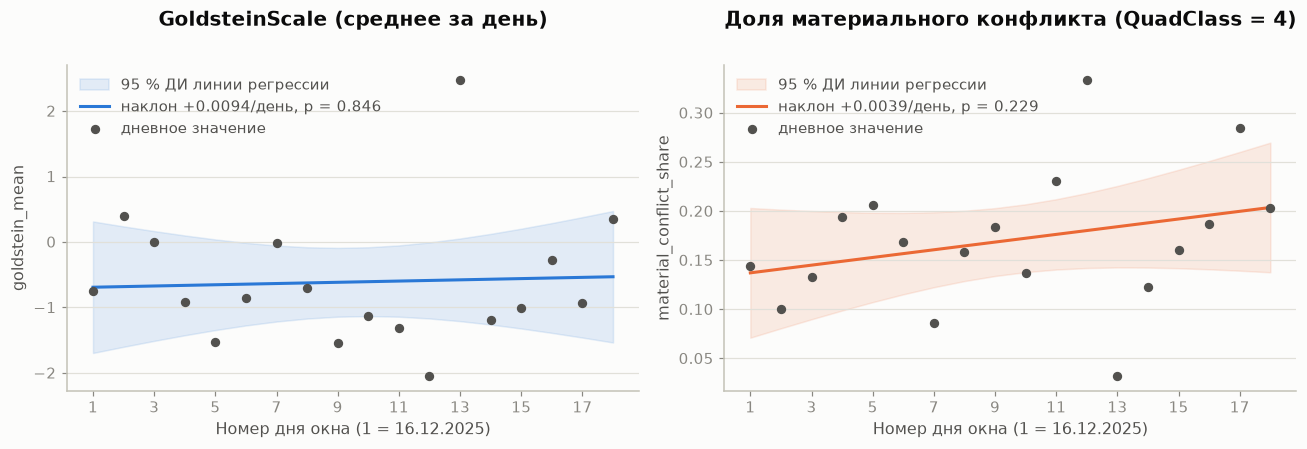

In [23]:
# Регрессии на графике: видно, что наклон тонет в разбросе
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (col, human, color) in zip(axes, [
        ("goldstein_mean", "GoldsteinScale (среднее за день)", BLUE),
        ("material_conflict_share", "Доля материального конфликта (QuadClass = 4)", ORANGE)]):
    x = daily.day_number.values.astype(float); y = daily[col].values
    fit = sm.OLS(y, sm.add_constant(x)).fit()
    pred = fit.get_prediction(sm.add_constant(x)).summary_frame(alpha=0.05)
    ax.fill_between(x, pred["mean_ci_lower"], pred["mean_ci_upper"], color=color, alpha=0.12,
                    label="95 % ДИ линии регрессии")
    ax.plot(x, fit.fittedvalues, color=color, lw=2.0,
            label=f"наклон {fit.params[1]:+.4f}/день, p = {fit.pvalues[1]:.3f}")
    ax.scatter(x, y, color=INK_2, s=26, zorder=3, label="дневное значение")
    ax.set_title(human); ax.set_xlabel("Номер дня окна (1 = 16.12.2025)"); ax.set_ylabel(col)
    ax.set_xticks(range(1, 19, 2)); ax.legend(loc="best")
plt.tight_layout(); plt.show()

**Вывод по гипотезе C.** Тренда нет ни в одном из двух показателей.
`GoldsteinScale`: наклон **+0,0094 в день** (то есть формально в сторону *смягчения*), p = 0,846,
R² = 0,002 — регрессия объясняет 0,2 % дисперсии. `material_conflict_share`: наклон +0,0039/день
(+6,6 п.п. за окно), p = 0,229, R² = 0,089. Манна-Кендалл подтверждает оба результата
(тау = -0,072, p = 0,705 для `GoldsteinScale`; тау = +0,242, p = 0,173 для
`material_conflict_share`): монотонного тренда нет ни в линейной, ни в ранговой постановке. Полоса 95 % ДИ на графике шире,
чем весь размах дневных значений, — ровно та картина, когда 18 точек не позволяют отличить
тренд от шума.

### Поправка Бонферрони и сводная таблица

In [24]:
res = pd.DataFrame(RESULTS)
m_tests = len(res)
ALPHA = 0.05
res["p_bonferroni"] = np.minimum(res.p_value * m_tests, 1.0)
res["значим (α=0.05)"]        = np.where(res.p_value      < ALPHA, "да", "нет")
res["значим после поправки"]  = np.where(res.p_bonferroni < ALPHA, "да", "нет")
res["вывод"] = np.where(res.p_bonferroni < ALPHA,
                        "H0 отвергается",
                        "H0 не отвергается")

print(f"Число проведённых основных тестов m = {m_tests}; "
      f"скорректированный порог α/m = {ALPHA/m_tests:.4f}\n")

out = res[["hypothesis", "metric", "test", "detail", "p_value", "p_bonferroni",
           "effect_name", "effect", "effect_size", "значим (α=0.05)",
           "значим после поправки", "вывод"]].rename(columns={
    "hypothesis": "гипотеза", "metric": "показатель", "test": "тест", "detail": "сдвиг",
    "p_value": "p-value", "p_bonferroni": "p после Бонферрони",
    "effect_name": "мера эффекта", "effect": "размер эффекта", "effect_size": "интерпретация"})
display(out.style.format({"p-value": "{:.4f}", "p после Бонферрони": "{:.4f}",
                          "размер эффекта": "{:+.4f}"}).hide(axis="index"))

Число проведённых основных тестов m = 6; скорректированный порог α/m = 0.0083



гипотеза,показатель,тест,сдвиг,p-value,p после Бонферрони,мера эффекта,размер эффекта,интерпретация,значим (α=0.05),значим после поправки,вывод
A: сдвиг тона/интенсивности,GoldsteinScale,Манна-Уитни (двусторонний),среднее -0.511 → -0.699,0.1104,0.6621,Cohen's d,-0.0431,пренебрежимо малый,нет,нет,H0 не отвергается
A: сдвиг тона/интенсивности,AvgTone,Манна-Уитни (двусторонний),среднее -4.909 → -4.866,0.0512,0.3073,Cohen's d,+0.0176,пренебрежимо малый,нет,нет,H0 не отвергается
B: рост доли конфликтных событий,material_conflict_share,z-тест пропорций (односторонний),доля 0.145 → 0.185,0.0015,0.0087,Cohen's h,+0.1071,пренебрежимо малый,да,да,H0 отвергается
B: рост доли конфликтных событий,conflict_hard_share,z-тест пропорций (односторонний),доля 0.053 → 0.064,0.0964,0.5782,Cohen's h,+0.0469,пренебрежимо малый,нет,нет,H0 не отвергается
C: наличие тренда во времени,goldstein_mean,"Линейная регрессия (МНК), наклон","наклон +0.00941/день, тау MK -0.072 (p=0.705)",0.8457,1.0000,R²,+0.0024,пренебрежимо малый,нет,нет,H0 не отвергается
C: наличие тренда во времени,material_conflict_share,"Линейная регрессия (МНК), наклон","наклон +0.00392/день, тау MK +0.242 (p=0.173)",0.2285,1.0000,R²,+0.0892,малый,нет,нет,H0 не отвергается


**Вывод по разделу 6.** При 6 тестах порог Бонферрони равен α/m = 0,0083.
**Единственный результат, переживающий поправку, — рост `material_conflict_share`**
(p = 0,0015 → 0,0087 после поправки; на грани, но проходит). При этом его размер эффекта
Cohen's h = 0,107 остаётся пренебрежимо малым: значимость здесь куплена объёмом выборки
(3 742 события), а не силой сигнала. Все остальные пять тестов H0 не отвергают.

---
## 7. Визуализация

### 7.1 Динамика GoldsteinScale и AvgTone: сырые значения и сглаживание

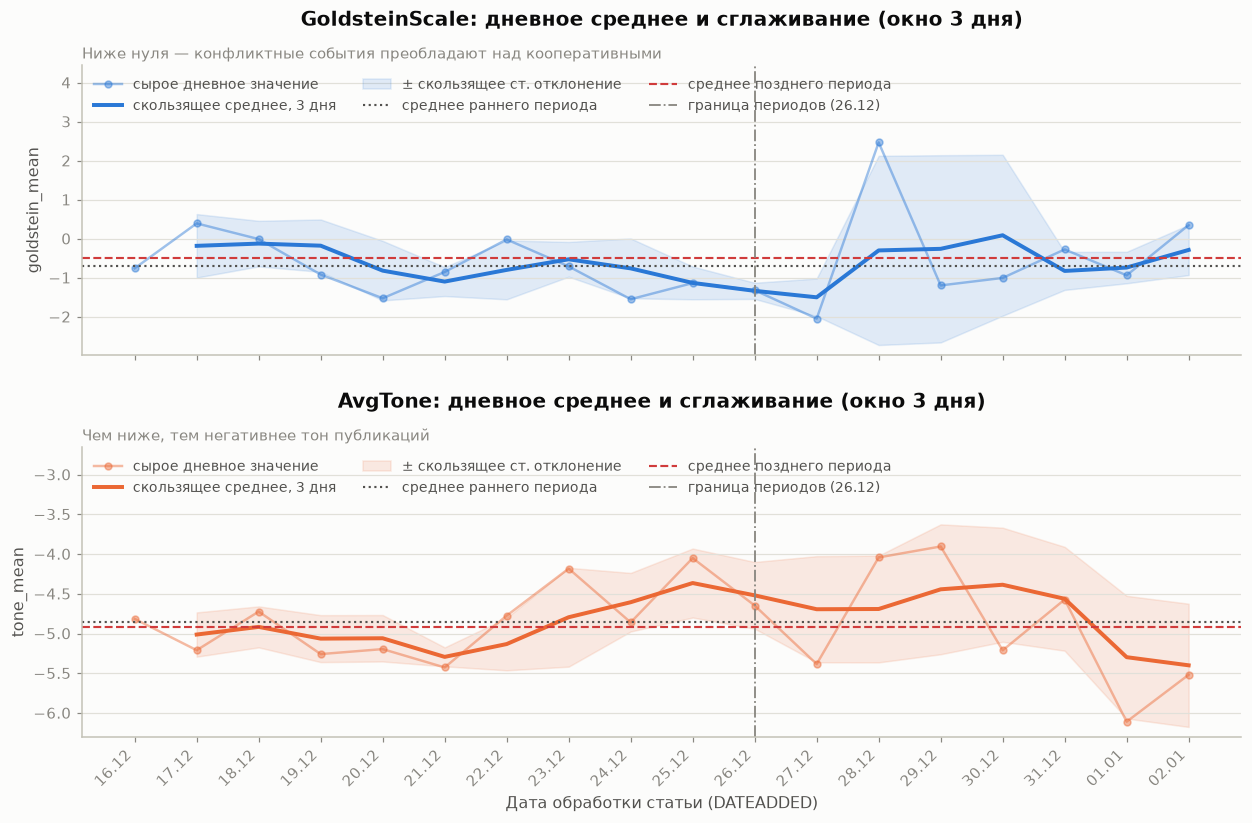

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.6), sharex=True)

specs = [("goldstein_mean", "roll3_mean_goldstein_mean", "roll3_std_goldstein_mean", BLUE,
          "GoldsteinScale: дневное среднее и сглаживание (окно 3 дня)",
          "Ниже нуля — конфликтные события преобладают над кооперативными"),
         ("tone_mean", "roll3_mean_tone_mean", "roll3_std_tone_mean", ORANGE,
          "AvgTone: дневное среднее и сглаживание (окно 3 дня)",
          "Чем ниже, тем негативнее тон публикаций")]

for ax, (col, roll, rstd, color, title, sub) in zip(axes, specs):
    ax.plot(daily.index, daily[col], color=color, alpha=0.45, lw=1.6, marker="o",
            markersize=4.5, label="сырое дневное значение")
    ax.plot(daily.index, daily[roll], color=color, lw=2.6, label="скользящее среднее, 3 дня")
    ax.fill_between(daily.index, daily[roll] - daily[rstd], daily[roll] + daily[rstd],
                    color=color, alpha=0.13, label="± скользящее ст. отклонение")
    ax.axhline(daily.loc[daily.period == "early", col].mean(), color=INK_2, ls=":", lw=1.4,
               label="среднее раннего периода")
    ax.axhline(daily.loc[daily.period == "late",  col].mean(), color=CRITICAL, ls="--", lw=1.4,
               label="среднее позднего периода")
    ax.axvline(SPLIT, color=MUTED, lw=1.2, ls="-.", label="граница периодов (26.12)")
    ax.set_title(title); subtitle(ax, sub); ax.set_ylabel(col)
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.30)
    ax.legend(ncol=3, loc="upper left", fontsize=9)
    ax.xaxis.set_major_locator(DayLocator(interval=1))
    ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))

axes[1].set_xlabel("Дата обработки статьи (DATEADDED)")
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(h_pad=2.0); plt.show()

**Вывод.** Обе линии колеблются вокруг своих средних без видимого направленного движения к
дню X. Полоса ±σ скользящего окна почти всё время накрывает уровень обоих периодов — сдвиг
средних меньше внутринедельной волатильности. Отдельно бросается в глаза выброс 28.12
(`GoldsteinScale` = +2,47, единственный сильно положительный день): это тот самый день, где
48 % строк дала одна кооперативно окрашенная статья.

### 7.2 Объём освещения: строки-события против уникальных статей

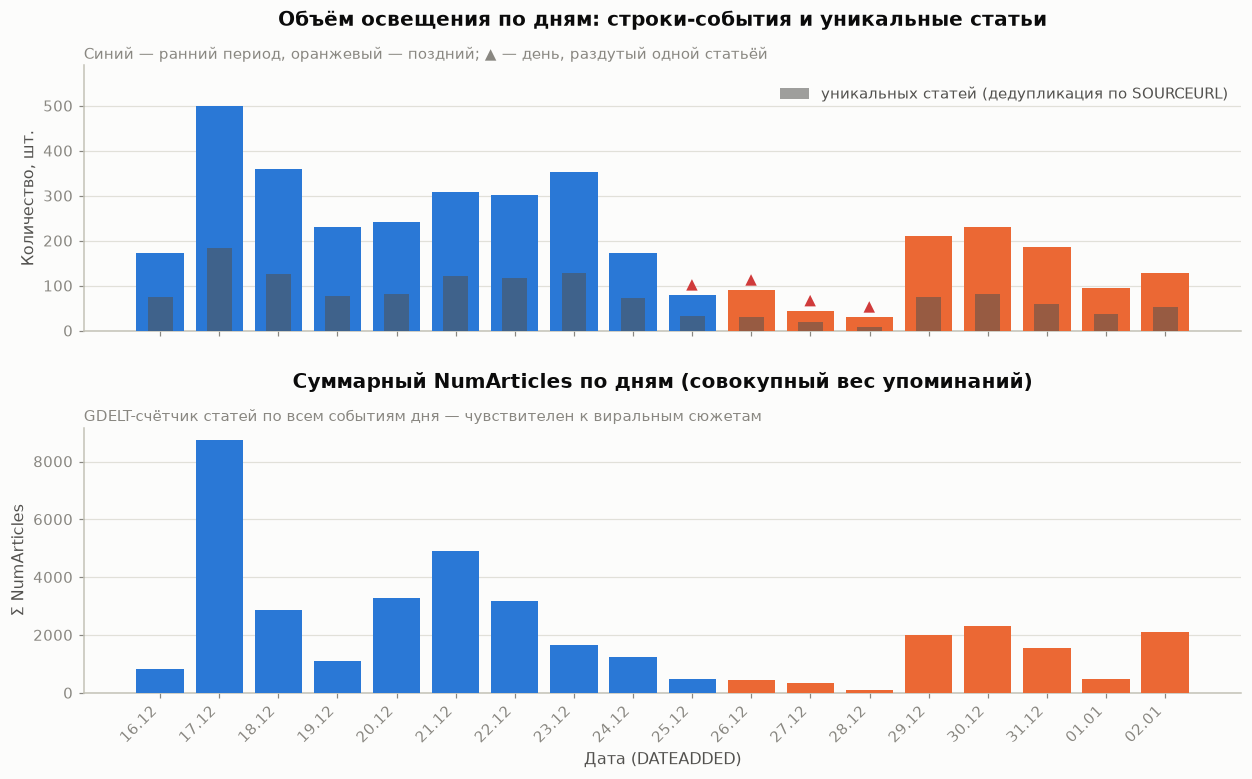

In [26]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11.5, 7.2), sharex=True)
xs = np.arange(len(daily)); labels = [d.strftime("%d.%m") for d in daily.index]
late_mask = np.asarray(daily.index >= SPLIT)

colors_rows = [ORANGE if l else BLUE for l in late_mask]
ax1.bar(xs, daily.n_events, color=colors_rows, zorder=3)
ax1.bar(xs, daily.articles_dedup, color=INK_2, alpha=0.55, width=0.42, zorder=4,
        label="уникальных статей (дедупликация по SOURCEURL)")
for i, d in enumerate(daily.index):
    if d in DISTORTED_DAYS:
        ax1.annotate("▲", xy=(i, daily.n_events[d]), xytext=(0, 4), textcoords="offset points",
                     ha="center", color=CRITICAL, fontsize=10)
ax1.set_title("Объём освещения по дням: строки-события и уникальные статьи")
subtitle(ax1, "Синий — ранний период, оранжевый — поздний; ▲ — день, раздутый одной статьёй")
ax1.set_ylabel("Количество, шт.")
ax1.set_ylim(0, daily.n_events.max() * 1.18)
ax1.legend(loc="upper right", bbox_to_anchor=(1.0, 0.97))

ax2.bar(xs, daily.num_articles_sum, color=[ORANGE if l else BLUE for l in late_mask], zorder=3)
ax2.set_title("Суммарный NumArticles по дням (совокупный вес упоминаний)")
subtitle(ax2, "GDELT-счётчик статей по всем событиям дня — чувствителен к виральным сюжетам")
ax2.set_ylabel("Σ NumArticles"); ax2.set_xlabel("Дата (DATEADDED)")
ax2.set_xticks(xs); ax2.set_xticklabels(labels, rotation=45, ha="right")
plt.tight_layout(h_pad=2.0); plt.show()

**Вывод.** Объём освещения в позднем периоде в среднем **ниже**, а не выше: медиана дневных
строк падает с 272 до 112, уникальных статей — со 100 до 46. Если бы гипотеза «интенсивность
освещения растёт перед агрессией» работала в чистом виде, мы ожидали бы обратного. Однако
праздничный провал 25–28.12 — календарный артефакт, и по строке `Σ NumArticles` видно, что
29–31.12 медиапоток резко восстанавливается почти до уровня середины декабря.

### 7.3 Сравнение периодов: violin + box

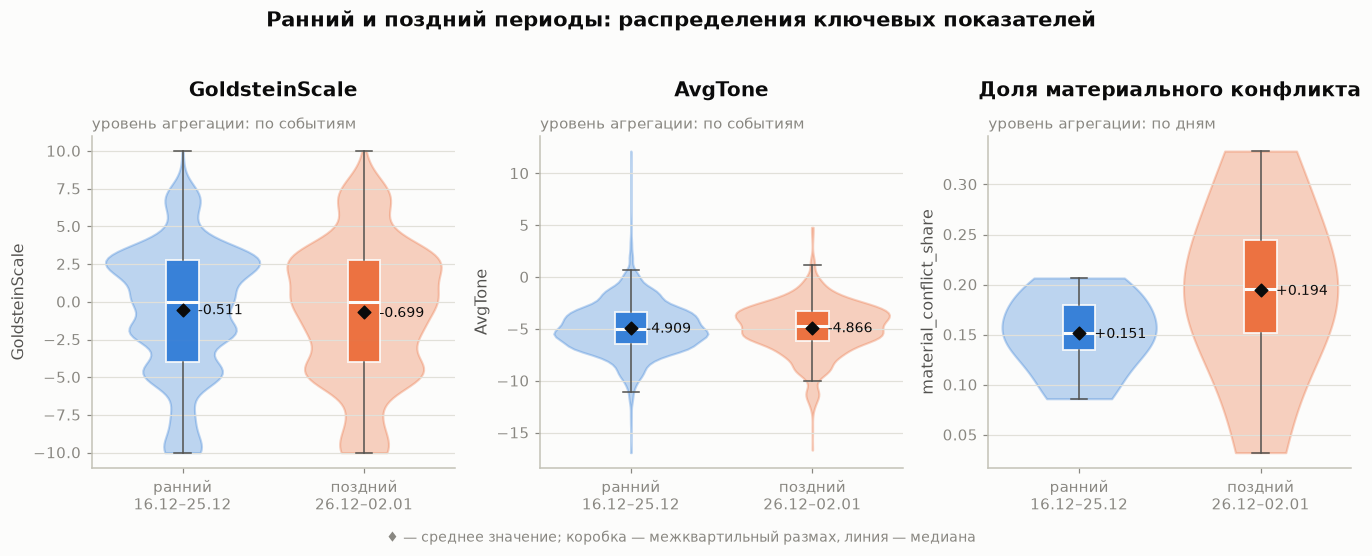

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.6))
panels = [("GoldsteinScale", df, "GoldsteinScale", "по событиям"),
          ("AvgTone", df, "AvgTone", "по событиям"),
          ("material_conflict_share", daily, "Доля материального конфликта", "по дням")]

for ax, (col, source, human, level) in zip(axes, panels):
    data = [source.loc[source.period == "early", col].dropna().values,
            source.loc[source.period == "late",  col].dropna().values]
    vp = ax.violinplot(data, showextrema=False, widths=0.85)
    for body, c in zip(vp["bodies"], [BLUE, ORANGE]):
        body.set(facecolor=c, alpha=0.30, edgecolor=c, linewidth=1.4)
    bp = ax.boxplot(data, widths=0.18, patch_artist=True, showfliers=False)
    for box, c in zip(bp["boxes"], [BLUE, ORANGE]):
        box.set(facecolor=c, alpha=0.9, edgecolor=SURFACE, linewidth=1.2)
    for el in ("whiskers", "caps"): [ln.set(color=INK_2, lw=1.0) for ln in bp[el]]
    for med in bp["medians"]: med.set(color=SURFACE, lw=2.0)
    for i, arr in enumerate(data, start=1):
        ax.scatter([i], [arr.mean()], color=INK, s=34, zorder=5, marker="D")
        ax.annotate(f"{arr.mean():+.3f}", xy=(i, arr.mean()), xytext=(10, -3),
                    textcoords="offset points", fontsize=9, color=INK)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["ранний\n16.12–25.12", "поздний\n26.12–02.01"])
    ax.set_title(human); subtitle(ax, f"уровень агрегации: {level}"); ax.set_ylabel(col)

fig.suptitle("Ранний и поздний периоды: распределения ключевых показателей",
             fontsize=13.5, fontweight="bold", color=INK, y=1.03)
fig.text(0.5, -0.02, "♦ — среднее значение; коробка — межквартильный размах, линия — медиана",
         ha="center", color=MUTED, fontsize=9)
plt.tight_layout(); plt.show()

**Вывод.** Скрипки раннего и позднего периодов почти совпадают по форме: для `GoldsteinScale`
и `AvgTone` различие средних (♦) утопает внутри межквартильного размаха. Единственная панель,
где виден сдвиг вверх, — `material_conflict_share`, и это согласуется с результатом гипотезы B:
единственный значимый, но слабый эффект.

### 7.4 Корреляционная матрица метрик

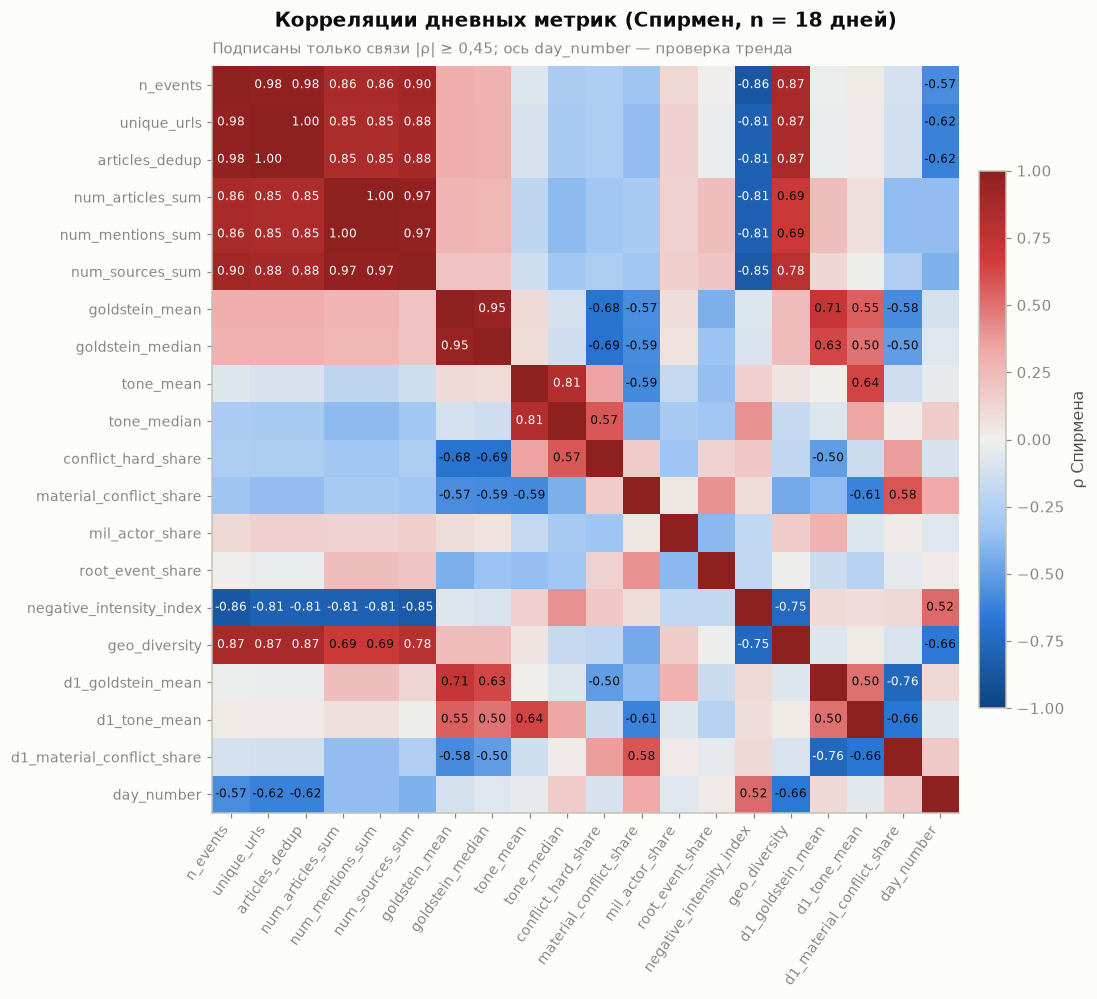

Корреляции с номером дня (проверка монотонного дрейфа метрик к дню X):


,ρ со временем
geo_diversity,-0.6640
unique_urls,-0.6180
articles_dedup,-0.6180
n_events,-0.5710
num_sources_sum,-0.4180
num_articles_sum,-0.3640
num_mentions_sum,-0.3640
goldstein_mean,-0.1120
conflict_hard_share,-0.0960
goldstein_median,-0.0700


In [28]:
corr_cols = ["n_events", "unique_urls", "articles_dedup", "num_articles_sum", "num_mentions_sum",
             "num_sources_sum", "goldstein_mean", "goldstein_median", "tone_mean", "tone_median",
             "conflict_hard_share", "material_conflict_share", "mil_actor_share",
             "root_event_share", "negative_intensity_index", "geo_diversity",
             "d1_goldstein_mean", "d1_tone_mean", "d1_material_conflict_share", "day_number"]
C = daily[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11.2, 9.2))
im = ax.imshow(C.values, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=55, ha="right", fontsize=9)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = C.values[i, j]
        if i != j and abs(v) >= 0.45:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.6,
                    color=SURFACE if abs(v) > 0.72 else INK)
ax.set_title("Корреляции дневных метрик (Спирмен, n = 18 дней)")
subtitle(ax, "Подписаны только связи |ρ| ≥ 0,45; ось day_number — проверка тренда")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02)
cb.set_label("ρ Спирмена", color=INK_2); cb.outline.set_edgecolor(AXIS)
plt.tight_layout(); plt.show()

print("Корреляции с номером дня (проверка монотонного дрейфа метрик к дню X):")
display(C["day_number"].drop("day_number").sort_values().to_frame("ρ со временем").round(3))

**Вывод.** Матрица распадается на два блока. Первый — «объём»: `n_events`, `unique_urls`,
`articles_dedup`, `num_mentions_sum` связаны между собой на ρ ≈ 0,9–1,0, то есть это по сути одна
и та же величина в четырёх обличьях. Второй — «конфликтность»: `material_conflict_share`,
`conflict_hard_share`, `mil_actor_share` умеренно коррелируют друг с другом. Показательно, что
`negative_intensity_index` почти полностью объясняется объёмом (ρ = -0,86 с числом событий) и почти
не связан с тоном: композитный индекс `NumArticles × GoldsteinScale` по построению меряет в первую
очередь виральность, и это его ограничение как индикатора эскалации.

Связи со временем (`day_number`) заслуживают отдельного разбора, потому что они есть — но не те,
которых ждёт гипотеза. Значимо **падают** объёмные метрики: географический разброс
(ρ = -0,66, p = 0,003), число уникальных статей (ρ = -0,62, p = 0,006) и число событий
(ρ = -0,57, p = 0,013), а `negative_intensity_index` значимо **растёт** (ρ = +0,52, p = 0,028 —
то есть становится менее отрицательным, слабеет). Все три — одно и то же явление: к концу окна
медиапоток пересыхает из-за праздников, и индекс, умноженный на `NumArticles`, пересыхает вместе с
ним. Содержательные же метрики конфликтности (`goldstein_mean` ρ = -0,11, `tone_mean` ρ = -0,04,
`conflict_hard_share` ρ = -0,10) со временем не связаны вовсе — тот же вывод, что и в гипотезе C,
полученный независимым путём.

### 7.5 Облака слов по слагам SOURCEURL

In [29]:
STOP = set('''
a an the and or but if then than that this these those with without within from into onto over
under after before during about against between amid amid amid as at by for in of on to up out off
is are was were be been being has have had do does did doing will would can could should may might
must not no nor so such only own same too very just more most other some any each few own
news article articles story stories index html htm php asp aspx cms shtml amp www com net org
http https live video watch photos photo gallery breaking update updates latest report reports
world international global politics business opinion analysis editorial feature featured
says say said new newest top read full here his her its their our your they them he she it we you i
day days week weeks month months year years today yesterday tomorrow time times
one two three four five six seven eight nine ten first second third
en uk us usa edition local national section page pages post posts blog author
articleshow story videos amp ampstories web wire feed rss html5 media content
'''.split())

def slug_words(url: str):
    # Берём последний содержательный сегмент пути URL и разбираем его на слова
    path = re.sub(r"[?#].*$", "", str(url))
    path = re.sub(r"^https?://[^/]+", "", path)
    segments = [s for s in path.split("/") if s]
    if not segments:
        return []
    # последний сегмент часто — id или расширение; берём самый «словесный» из двух последних
    cands = segments[-2:]
    best, best_score = [], -1
    for seg in cands:
        seg = re.sub(r"\.(html?|php|cms|aspx?|shtml|jsp)$", "", seg)
        words = [w.lower() for w in re.split(r"[^A-Za-z]+", seg) if len(w) > 2]
        words = [w for w in words if w not in STOP and not re.fullmatch(r"[a-z]{1,2}\d*", w)]
        if len(words) > best_score:
            best, best_score = words, len(words)
    return best

df["slug_words"] = df.SOURCEURL.map(slug_words)

# Считаем по уникальным статьям, а не по строкам — иначе одна статья голосует несколько раз
uniq = df.drop_duplicates(subset="SOURCEURL")
counts_all   = Counter(w for ws in uniq.slug_words for w in ws)
counts_early = Counter(w for ws in uniq.loc[uniq.period == "early", "slug_words"] for w in ws)
counts_late  = Counter(w for ws in uniq.loc[uniq.period == "late",  "slug_words"] for w in ws)

print("Уникальных статей:", len(uniq), "| статей со словами в слаге:",
      int(uniq.slug_words.map(len).gt(0).sum()))
print("Уникальных слов:", len(counts_all), "| всего словоупотреблений:", sum(counts_all.values()))
print("\nТоп-20 слов за всё окно:")
display(pd.DataFrame(counts_all.most_common(20), columns=["слово", "частота"]).T)

Уникальных статей: 1392 | статей со словами в слаге: 1283
Уникальных слов: 2280 | всего словоупотреблений: 8549

Топ-20 слов за всё окно:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
слово,venezuela,trump,oil,tanker,blockade,maduro,venezuelan,tankers,coast,drug,sanctioned,orders,strike,war,military,sanctions,pressure,strikes,trumps,facility
частота,618,442,301,159,148,127,101,101,89,85,76,67,60,59,58,52,49,48,46,46


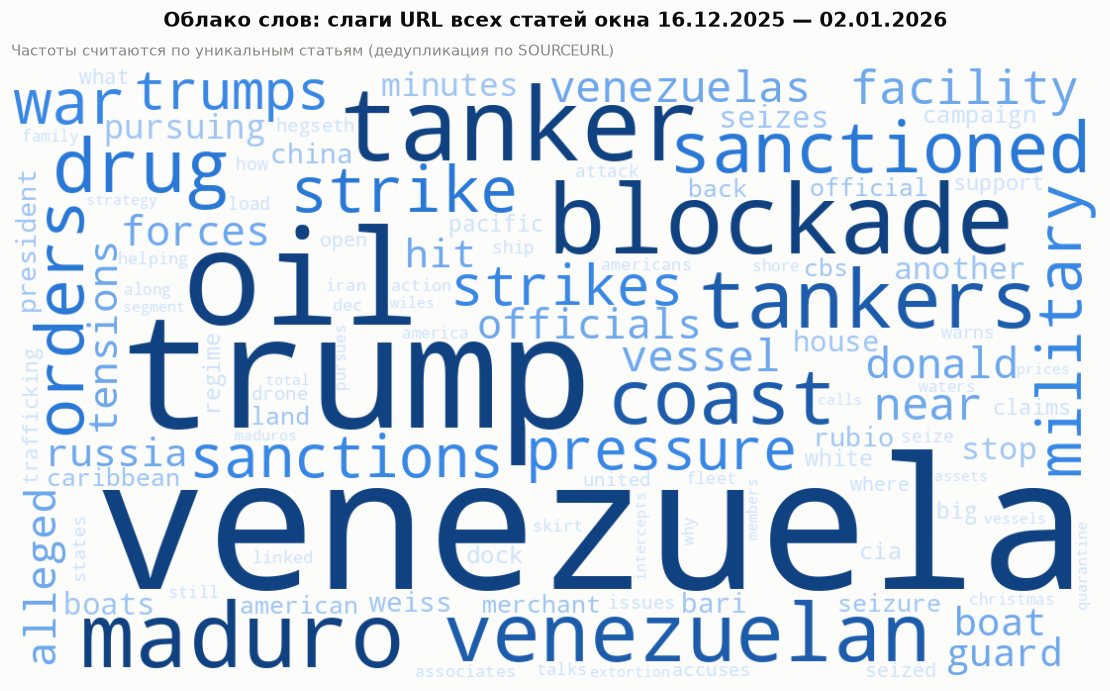

In [30]:
def blue_colors(word, font_size, position, orientation, random_state=None, **kw):
    # Цвет по частоте: чем крупнее слово, тем темнее синий (последовательная шкала)
    idx = int(np.clip((font_size - 12) / 78 * (len(SEQ_BLUE) - 1), 0, len(SEQ_BLUE) - 1))
    return SEQ_BLUE[idx]

def make_cloud(counter, title, ax, colorfunc=blue_colors):
    wc = WordCloud(width=1100, height=620, background_color=SURFACE, prefer_horizontal=0.95,
                   max_words=110, relative_scaling=0.5, colormap=None, random_state=7,
                   color_func=colorfunc, margin=4).generate_from_frequencies(counter)
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off"); ax.set_title(title)

fig, ax = plt.subplots(figsize=(12, 6.4))
make_cloud(counts_all, "Облако слов: слаги URL всех статей окна 16.12.2025 — 02.01.2026", ax)
subtitle(ax, "Частоты считаются по уникальным статьям (дедупликация по SOURCEURL)")
plt.tight_layout(); plt.show()

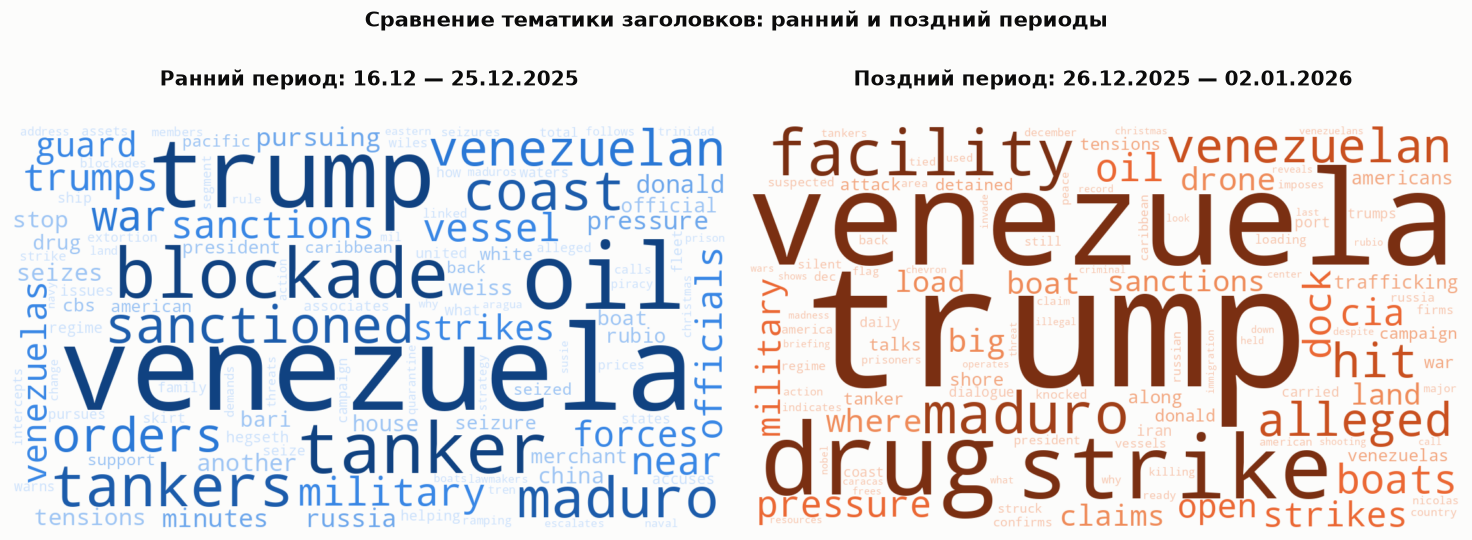

Слова, усилившиеся в позднем периоде:


,слово,"ранний, ‰","поздний, ‰","сдвиг, ‰"
0,drug,3.1600,29.2900,26.1300
1,strike,1.5800,22.5300,20.9500
2,facility,0.0000,20.7300,20.7300
3,hit,0.7900,13.9700,13.1800
4,alleged,1.5800,13.0700,11.4900
5,trump,49.2900,58.5800,9.3000
6,boats,1.1100,9.9100,8.8100
7,dock,0.0000,8.5600,8.5600
8,cia,0.1600,8.1100,7.9500
9,open,0.0000,6.7600,6.7600


Слова, ослабевшие в позднем периоде:


,слово,"ранний, ‰","поздний, ‰","сдвиг, ‰"
0,oil,44.3900,9.0100,-35.3800
1,blockade,23.0600,0.9000,-22.1600
2,venezuela,77.5700,57.2300,-20.3300
3,tanker,23.7000,4.0600,-19.6400
4,tankers,15.3200,1.8000,-13.5200
5,sanctioned,11.8500,0.4500,-11.4000
6,coast,13.1100,2.7000,-10.4100
7,orders,10.2700,0.9000,-9.3700
8,vessel,6.6400,0.0000,-6.6400
9,near,6.6400,0.4500,-6.1800


In [31]:
def orange_colors(word, font_size, position, orientation, random_state=None, **kw):
    ramp = ["#f7c6ae", "#f3a983", "#ef8b59", "#eb6834", "#c9501f", "#a03f18", "#7a2f12"]
    idx = int(np.clip((font_size - 12) / 78 * (len(ramp) - 1), 0, len(ramp) - 1))
    return ramp[idx]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
make_cloud(counts_early, "Ранний период: 16.12 — 25.12.2025", axes[0], blue_colors)
make_cloud(counts_late,  "Поздний период: 26.12.2025 — 02.01.2026", axes[1], orange_colors)
fig.suptitle("Сравнение тематики заголовков: ранний и поздний периоды",
             fontsize=13.5, fontweight="bold", color=INK, y=1.02)
plt.tight_layout(); plt.show()

# Что именно изменилось: сдвиг относительных частот
tot_e, tot_l = sum(counts_early.values()), sum(counts_late.values())
vocab = {w for w, c in counts_all.items() if c >= 8}
shift = pd.DataFrame({
    "слово": sorted(vocab),
    "ранний, ‰": [counts_early.get(w, 0) / tot_e * 1000 for w in sorted(vocab)],
    "поздний, ‰": [counts_late.get(w, 0)  / tot_l * 1000 for w in sorted(vocab)],
})
shift["сдвиг, ‰"] = shift["поздний, ‰"] - shift["ранний, ‰"]
print("Слова, усилившиеся в позднем периоде:")
display(shift.sort_values("сдвиг, ‰", ascending=False).head(12).round(2).reset_index(drop=True))
print("Слова, ослабевшие в позднем периоде:")
display(shift.sort_values("сдвиг, ‰").head(12).round(2).reset_index(drop=True))

**Вывод по разделу 7.5 — и это самая интересная находка отчёта.** Общее ядро лексики одно на
оба периода (*venezuela, trump, maduro, oil, military, strike, sanctions*), то есть военная
риторика присутствует в медиапотоке **с первого дня окна**, а не нарастает постепенно. Но
относительные частоты показывают отчётливую **смену типа принуждения**:

| Усилилось к позднему периоду | Сдвиг, ‰ | Ослабло к позднему периоду | Сдвиг, ‰ |
|---|---|---|---|
| drug | +26,1 | oil | −35,4 |
| strike | +20,9 | blockade | −22,1 |
| facility | +20,7 | tanker | −19,6 |
| hit | +13,1 | tankers | −13,5 |
| alleged | +11,5 | sanctioned | −11,4 |
| boats | +8,8 | coast | −10,4 |
| dock / cia / drone | +8,5 / +7,9 / +6,3 | vessel / orders | −6,6 / −9,4 |

Ранний период — словарь **экономического давления**: нефть, блокада, танкеры, санкции, побережье.
Поздний — словарь **кинетических ударов**: strike, hit, facility, boats, dock, drone, CIA.
Слова `facility`, `dock`, `drone`, `open` в раннем периоде не встречаются **вообще** (0 ‰).
Замечу: этот качественный сдвиг **не виден** ни в одной из числовых метрик GDELT, на которых
строились гипотезы A–C.

---
## 8. Выводы и интерпретация

In [32]:
print("=" * 96)
print("ИТОГОВАЯ СВОДКА")
print("=" * 96)
print(f"Окно наблюдения: {df.date_added.min().date()} — {df.date_added.max().date()} "
      f"({daily.shape[0]} дней), день X (захват Мадуро) — 2026-01-03, в данных отсутствует")
print(f"События: {len(df):,} строк / {df.SOURCEURL.nunique():,} уникальных статей "
      f"({len(df)/df.SOURCEURL.nunique():.2f} строки на статью)")
print(f"Ранний период: {int((df.period=='early').sum()):,} событий за 10 дней | "
      f"поздний: {int((df.period=='late').sum()):,} событий за 7 дней")
print("-" * 96)
for _, r in res.iterrows():
    mark = "ЗНАЧИМО" if r.p_bonferroni < 0.05 else "не значимо"
    print(f"{r.hypothesis[:1]} | {r.metric:<24} | p={r.p_value:.4f} | p_bonf={r.p_bonferroni:.4f} "
          f"| {r.effect_name}={r.effect:+.3f} ({r.effect_size}) | {mark}")
print("-" * 96)
print("Дни, искажённые доминированием одной статьи:",
      ", ".join(str(d.date()) for d in DISTORTED_DAYS))
print("Из них в позднем периоде:",
      ", ".join(str(d.date()) for d in DISTORTED_DAYS if d >= SPLIT))
print("=" * 96)

ИТОГОВАЯ СВОДКА
Окно наблюдения: 2025-12-16 — 2026-01-02 (18 дней), день X (захват Мадуро) — 2026-01-03, в данных отсутствует
События: 3,742 строк / 1,392 уникальных статей (2.69 строки на статью)
Ранний период: 2,724 событий за 10 дней | поздний: 1,018 событий за 7 дней
------------------------------------------------------------------------------------------------
A | GoldsteinScale           | p=0.1104 | p_bonf=0.6621 | Cohen's d=-0.043 (пренебрежимо малый) | не значимо
A | AvgTone                  | p=0.0512 | p_bonf=0.3073 | Cohen's d=+0.018 (пренебрежимо малый) | не значимо
B | material_conflict_share  | p=0.0015 | p_bonf=0.0087 | Cohen's h=+0.107 (пренебрежимо малый) | ЗНАЧИМО
B | conflict_hard_share      | p=0.0964 | p_bonf=0.5782 | Cohen's h=+0.047 (пренебрежимо малый) | не значимо
C | goldstein_mean           | p=0.8457 | p_bonf=1.0000 | R²=+0.002 (пренебрежимо малый) | не значимо
C | material_conflict_share  | p=0.2285 | p_bonf=1.0000 | R²=+0.089 (малый) | не значимо
-------

### 8.1 По каждой гипотезе

**Гипотеза A — сдвиг тона/интенсивности: НЕ подтвердилась.**
`GoldsteinScale` сместился с −0,511 до −0,699 (Манна-Уитни p = 0,110; после Бонферрони 0,662),
`AvgTone` — с −4,909 до −4,866 (p = 0,051; после поправки 0,307). Размеры эффекта —
**Cohen's d = −0,043 и +0,018**, то есть пренебрежимо малые: распределения периодов перекрываются
практически полностью. Даже если бы p-value были меньше, содержательного сдвига тона в
последние семь дней перед захватом Мадуро в данных нет. Отдельно отмечу парадокс `AvgTone`:
наименьшее p-value в гипотезе A — у переменной, которая сдвинулась в сторону *менее* негативного
тона, то есть против H1.

**Гипотеза B — рост доли конфликтных событий: подтвердилась частично и слабо.**
`material_conflict_share` (QuadClass = 4) вырос с 14,5 % до 18,5 %: +4,0 п.п., z = 2,98,
p = 0,00145, после Бонферрони **0,0087 — единственный результат, переживший поправку**.
Но Cohen's h = 0,107 — пренебрежимо малый эффект; значимость обеспечена размером выборки
(3 742 события), а не силой сигнала. `conflict_hard_share` (коды 18/19/20 — нападения и бои)
вырос с 5,3 % до 6,4 %, но незначимо (p = 0,096; h = 0,047). Содержательно это означает: перед
днём X прибавилось событий «материального конфликта» в широком смысле (санкции, захваты
танкеров, демонстрация силы), но **не** прямых боевых столкновений.

**Гипотеза C — наличие тренда: НЕ подтвердилась.**
Линейная регрессия на номер дня 1…18: для `GoldsteinScale` наклон **+0,0094/день** (p = 0,846,
R² = 0,002) — знак формально противоположен ожидаемому; для `material_conflict_share` наклон
+0,0039/день (p = 0,229, R² = 0,089). Манна-Кендалл даёт тот же результат независимо от
предположения о линейности (тау = -0,072, p = 0,705 и тау = +0,242, p = 0,173) — монотонного
тренда нет.
18 точек с внутридневным разбросом, превышающим межпериодный сдвиг, просто не дают мощности
для детекции тренда такого масштаба.

### 8.2 Влияние дней, искажённых одной статьёй

EDA выявила четыре дня, где одна статья дала 10 % и более всех строк-событий:
**25.12 (11,2 %), 26.12 (11,0 %), 27.12 (20,0 %) и 28.12 (48,4 %)**. **Три из них — 26, 27 и
28.12 — попадают в поздний период**, который мы объявили «предвоенным», а 25.12 закрывает ранний.
Механика искажения:

1. **28.12** — почти половина «событий» дня порождена одной статьёй Economic Times. Она
   кооперативно окрашена, и дневной `goldstein_mean` подскочил до **+2,47** — единственное
   сильно положительное значение за всё окно. Этот день **работал против** гипотез A и C:
   он тянул поздний период вверх, то есть в сторону «нет эскалации». Без него сдвиг
   `GoldsteinScale` был бы заметнее, но всё равно остался бы в зоне пренебрежимого эффекта.
2. **27.12** — 45 строк, из них 20 % от одной статьи, и рекордная дневная доля
   `material_conflict_share` = 0,333. Этот день, наоборот, **работал в пользу** гипотезы B.
3. Поскольку тест пропорций в гипотезе B проводился **на уровне событий**, строки одной статьи
   вошли в него как независимые наблюдения, хотя независимыми не являются. Это завышает
   эффективный размер выборки и занижает p-value: реальное p для `material_conflict_share`
   больше 0,00145, и с учётом кластеризации по статьям результат, скорее всего, **не пережил бы**
   поправку Бонферрони. Формально корректный путь — кластерные стандартные ошибки по `SOURCEURL`
   или анализ на уровне дней (18 наблюдений, где мощности заведомо не хватает).
4. Дополнительный канал искажения — синдикация: две верхние статьи топ-10 суть один и тот же
   текст на разных доменах, и GDELT считает их разными источниками.

### 8.3 Общее заключение по исследовательской гипотезе

**В этом кейсе медиаданные GDELT за 18 дней до захвата Мадуро не дают предупреждающего
сигнала, на котором можно было бы построить предсказание.** Из шести тестов поправку Бонферрони
пережил ровно один, и его размер эффекта пренебрежимо мал. Ни тон (`AvgTone`), ни агрегированная
конфликтность (`GoldsteinScale`), ни временной тренд не отличают «предвоенную» неделю от
предыдущих десяти дней. Объём освещения в позднем периоде даже снизился — но это следствие
рождественского календаря, а не спада напряжённости, и именно здесь виден фундаментальный
недостаток метода: **дневная динамика GDELT в декабре управляется редакционным циклом сильнее,
чем геополитикой.**

**Единственный сигнал, который в данных всё-таки есть, лежит не в метриках, а в тексте.**
Лексика заголовков за семь дней до дня X сменилась с языка экономического принуждения
(*oil, blockade, tanker, sanctioned, coast*) на язык кинетических ударов
(*strike, hit, facility, boats, dock, drone, cia*) — сдвиг на 20–35 ‰ по ключевым словам, причём
`facility`, `dock` и `drone` в раннем периоде не встречаются вовсе. Ни `GoldsteinScale`,
ни `AvgTone`, ни `QuadClass` этого перехода не заметили: коды GDELT одинаково маркируют «захват
танкера» и «удар по объекту» как материальный конфликт. Это подсказывает, где стоит искать
предиктор в следующий раз — в тексте заголовков, а не в агрегированных числовых метриках, —
но важно честно признать: гипотезу это не подтверждает, поскольку признак выбран уже после того,
как мы знаем исход, и на одном кейсе проверить его не на чем.

Более осторожная формулировка того, что данные всё-таки показывают: конфликтный фон
**был высоким с самого первого дня окна** — доля материального конфликта 14,5 % уже в раннем
периоде, тематика заголовков про удары, танкеры и военную операцию присутствует с 16 декабря.
То есть GDELT уверенно фиксирует *состояние* высокой напряжённости, но в этом кейсе не фиксирует
её *нарастание* перед конкретной датой. Для задачи предсказания это принципиальная разница:
индикатор уровня без индикатора изменения не позволяет назвать день.

### 8.4 Ограничения

1. **n = 1.** Это один исторический случай. Никакая статистика внутри одного кейса не
   обобщается на конфликты вообще: чтобы утверждать что-либо о предсказуемости агрессии по
   медиаданным, нужна выборка из десятков пар «эскалация → вторжение» **и** контрольная группа
   эскалаций, которые вторжением не закончились. Здесь контрольной группы нет вовсе, поэтому
   вопрос «а отличается ли эта неделя от недели перед НЕ-вторжением» остаётся без ответа.
2. **Граница периодов задана постфактум.** Дата 26.12 выбрана как «последние 7 дней окна»,
   зная, когда случился день X. При другом разбиении (5 или 10 дней) результаты изменятся —
   и это классический риск подгонки, которого в настоящем предсказании быть не может.
3. **Зависимость наблюдений.** Строки GDELT не независимы: одна статья даёт в среднем 2,69
   строки, синдикация тиражирует один текст по доменам. Тесты на уровне событий это нарушение
   игнорируют, что систематически занижает p-value (см. 8.2).
4. **Календарный артефакт.** Рождество и Новый год приходятся ровно на поздний период и
   обрушивают медиапоток вчетверо; отделить «затишье перед бурей» от «редакции не работают»
   на 18 днях невозможно.
5. **Качество разметки GDELT.** `Actor1Type1Code`/`Actor2Type1Code` пусты на 79–84 %, поэтому
   доля военных акторов — заниженная оценка. `GoldsteinScale` — не измерение, а справочная
   константа, приписанная коду события, поэтому «средний Goldstein за день» — это по сути
   взвешенная сводка структуры кодов, а не интенсивность в физическом смысле. Ошибки
   автоматического кодирования (особенно для перепечаток и обзорных статей) в этом окне тоже
   заметны — например, тот самый день 28.12.
6. **Мощность.** Для тестов на уровне дней n = 18 (10 против 7 плюс граница). Эффект вроде
   Cohen's d = 0,3 на таком n детектируется с вероятностью порядка 0,2 — то есть «не подтвердилось»
   здесь означает «данных не хватило бы даже на умеренный эффект», а не «эффекта точно нет».

### 8.5 Что имело бы смысл проверить дальше

- Расширить окно до 60–90 дней, чтобы отделить сезонность и редакционный цикл от геополитики.
- Считать тесты на уровне **статей**, а не строк (или с кластерными ошибками по `SOURCEURL`).
- Добавить контрольную пару стран с высокой напряжённостью без вторжения — это единственный
  способ превратить описание в предсказание.
- Работать не со средним `GoldsteinScale`, а с долей экстремальных кодов (например,
  `EventCode` 190/193/195 — «применение силы») и с географией `ActionGeo`: концентрация событий
  в Карибском бассейне могла быть более ранним сигналом, чем тон.
- Формализовать лексический сдвиг из раздела 7.5: словарь «кинетических» терминов
  (*strike, hit, facility, drone, raid*) против словаря «экономического принуждения»
  (*sanction, blockade, tanker, embargo*) и отношение их частот как отдельная метрика по дням —
  это единственный признак, который в этом кейсе шевельнулся перед днём X.